## 23344072 , 贾梓杏

# 微分方程求解练习

In [ ]:
from scipy.integrate import odeint, quad
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video
%matplotlib widget

### 关于Magic Command的提醒
上一节的导入过程中，有`%matplotlib widget`这样的命令。`%`开头的命令不是 Python 语法，而是 IPython 内核 提供的特殊指令
它会被 Jupyter 的 "preprocessor" 拦截并处理。最终调用 `matplotlib.use()` 来切换绘图后端（backend）。像`inline`就是静态图片嵌入，而`widget`就是动态交互。

如果出现下面的报错，
```bash
ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']
```
则应该`conda install ipyml`

当然，在下面的code当中，也给出了
```python
from IPython.display import HTML

ani = FuncAnimation(fig, update, frames=n_frame, interval=10, repeat=False)
HTML(ani.to_jshtml())
```
这样的解决方式

---
# 第一部分：常微分方程求解练习

## 受推力与阻尼运动的一阶一维常微分方程求解

使用`scipy.integrate.odeint`，求解受推力与阻尼运动的一阶一维常微分方程
$m\dot{v} = f - C  v^2$ 的解$v(t)$， 绘制速度$v$随时间$t$变化的曲线。其中：
 - 参数：
    - 质量 $𝑚=2$
    - 驱动力函数形式 $f(t)=e^{-t}$
    - 阻尼常数 $C=0.1$
 - 初始条件：$v(t_0)=1$
 - $t$范围为0到10，取等间隔100个点。

参考结果：
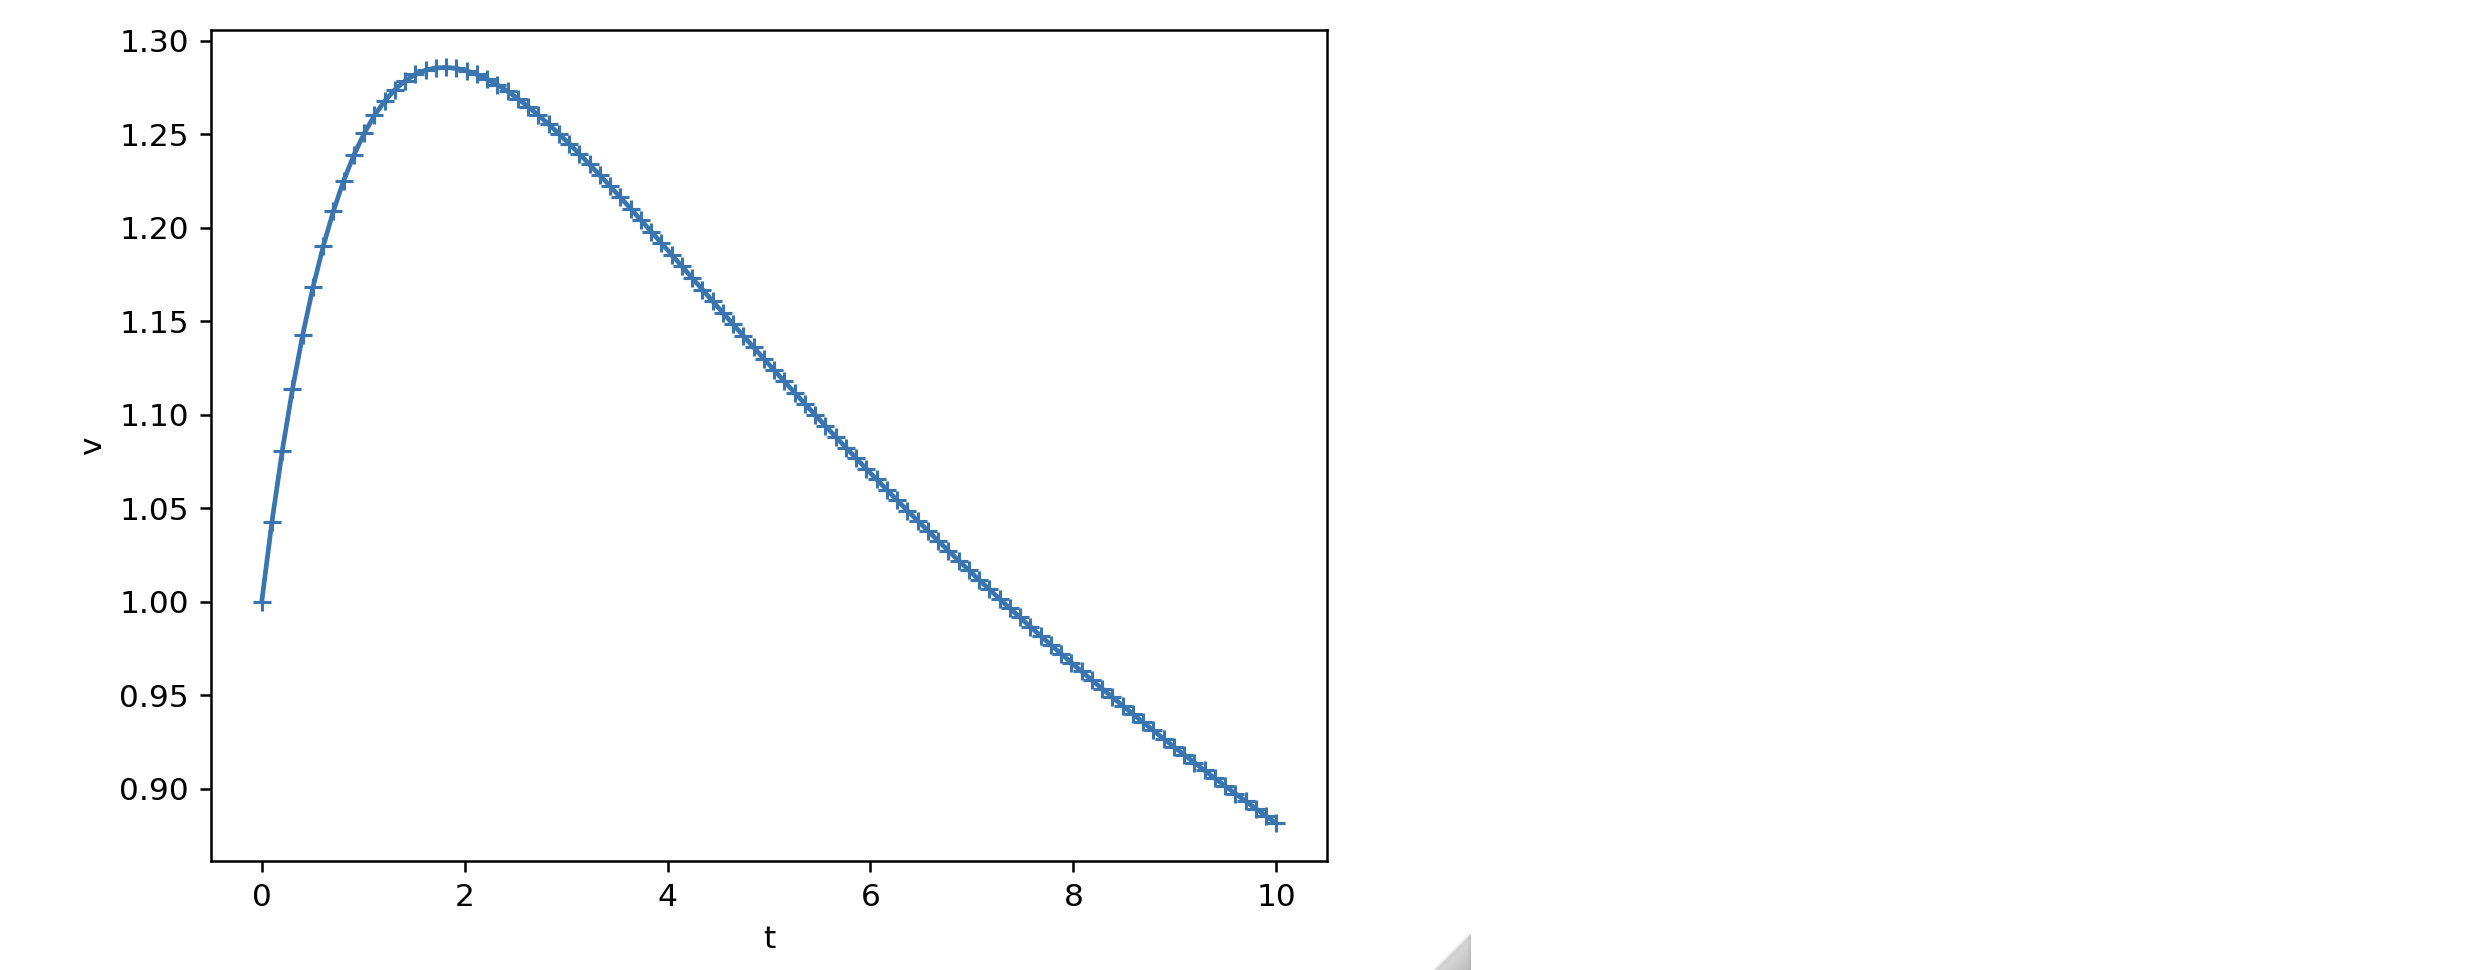

In [ ]:
def dvdt(v, t, m, C):
    f = np.exp(-t)
    return (f - C*v**2)/m

m = 2
C = 0.1
t = np.linspace(0, 10, 100)
v0 = 1
v = odeint(dvdt, v0, t,args =(m,C) )
plt.figure(figsize=(8, 5))
plt.plot(t, v, marker='+', color='#1f77b4')
plt.xlabel('t')
plt.ylabel('v')
plt.grid(True)
plt.show()

## 弹簧振动的二阶一维常微分方程
使用scipy.integrate.odeint，求解弹簧振子的常微分方程：$m \ddot{r} + C \dot{r} + k r = f(t)$，其中 $f(t) = \left \{ \begin{matrix} b & 0 \le t < 10 \\ 0 & t\ge 10 \end{matrix}\right . $, 即前10个时间单位有恒定外力$b$，之后没有外力。绘制偏离平衡位置的位移$r$和速度$v$随时间的演化曲线。
其中：
- 参数：
    - 质量$m=1$,
    - 阻尼系数$C=0.5$
    - 弹簧常数$k = 2$
    - 外力$b = 10$ 
- 初始条件：$r(t_0)= 0, \dot{r}(t_0) = 0$
- $t$的范围为0到40，取等间隔100个点

思路：
- 定义速度$v = \dot{r}$,将二阶方程转为二维一阶方程组:
  
   $ \left \{ \begin{matrix} v =  \dot{r} \\ m \dot{v} + C v + k r =  f(t) \end{matrix}\right .$

- 同时求解$r$和$v$，对应导函数$\dot{r}$和$\dot{v}$表达式分别为

   $ \left \{ \begin{matrix} \dot{r} = v  \\ \dot{v} = (f(t) - C v - k r)/m \end{matrix}\right .$


参考结果：
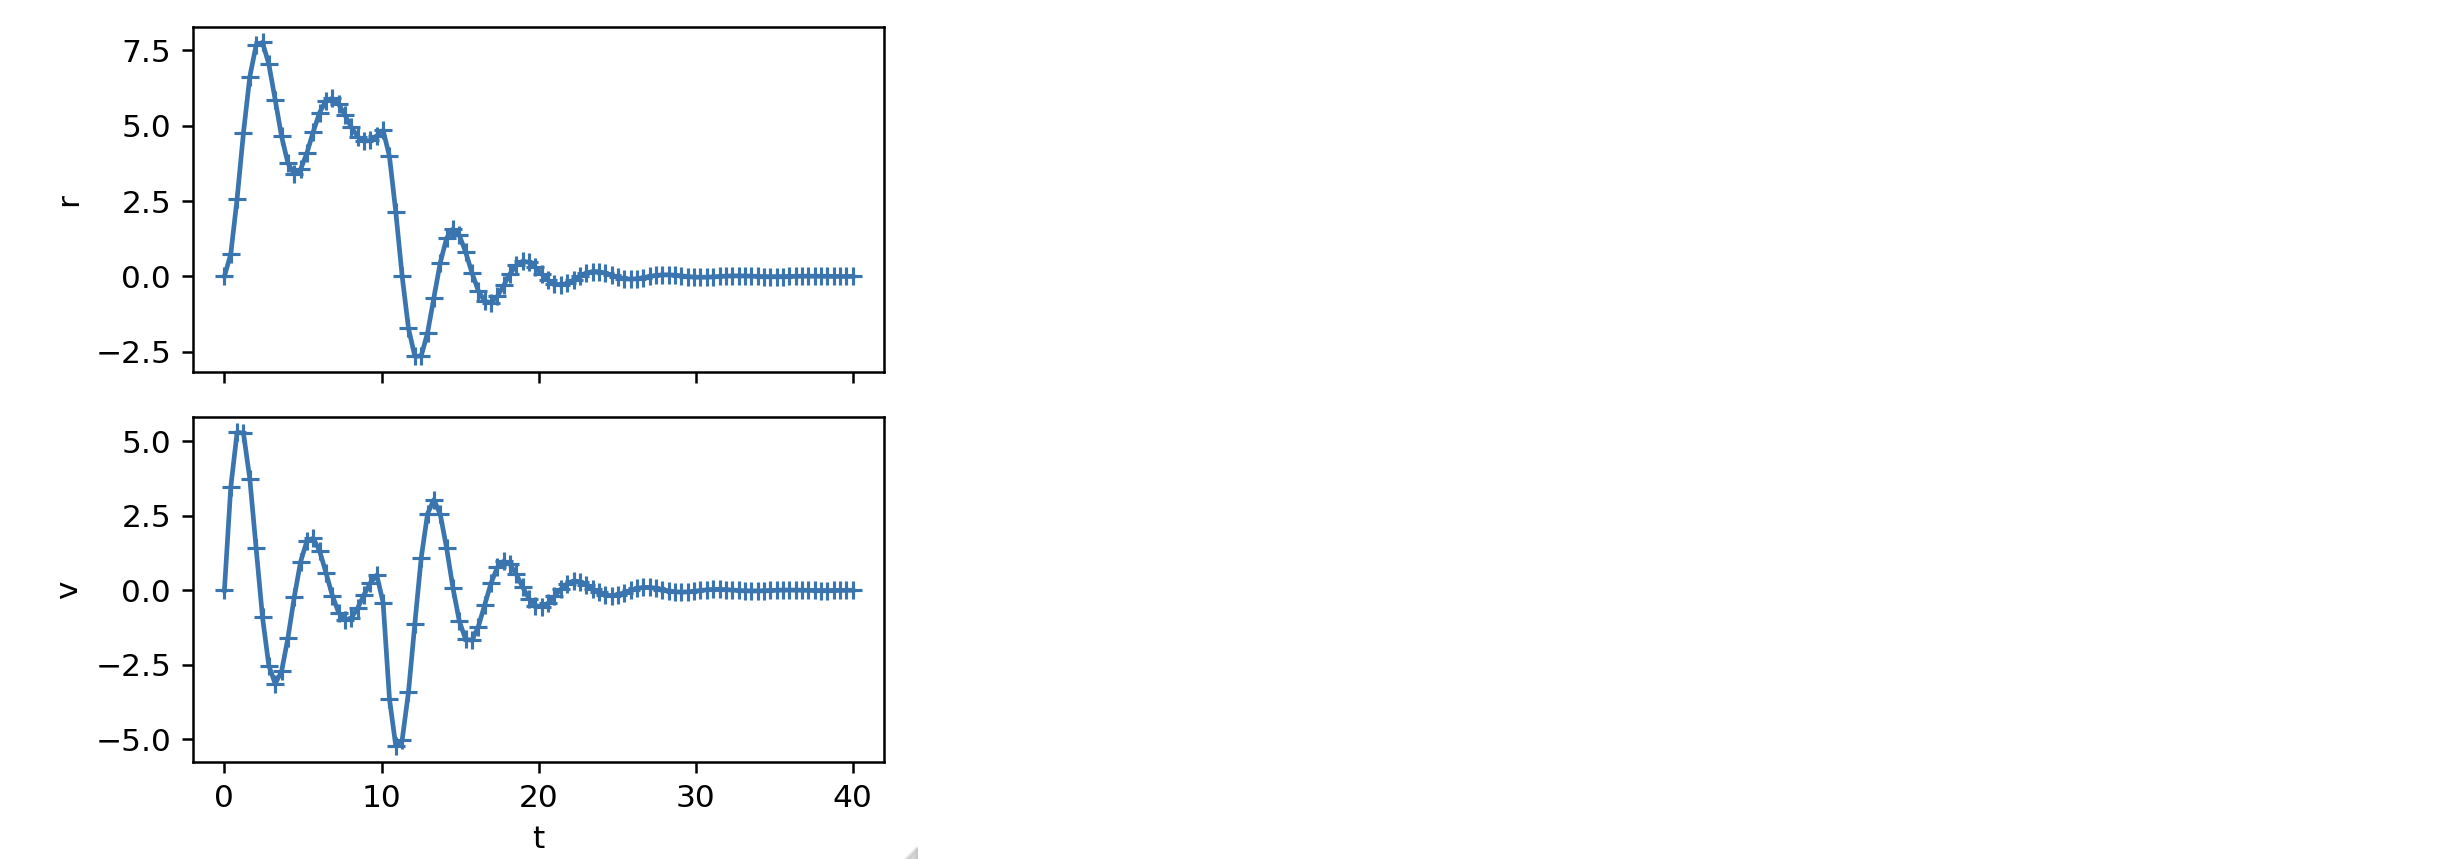

In [ ]:
# 定义一阶微分方程组
def dy_dt(y, t):
    m = 1
    C = 0.5
    k = 2
    b = 10
    r, v = y
    # 分段外力判断
    if t < 10:
        f = b
    else:
        f = 0
    drdt = v
    dvdt = (f - C*v - k*r) / m
    return [drdt, dvdt]

# 生成时间序列、初始条件
t2 = np.linspace(0, 40, 100)
y0 = [0, 0]  # [r(0), v(0)]

# 数值求解
sol = odeint(dy_dt, y0, t2)
r_solution = sol[:, 0]  # 位移随时间变化

# 绘制位移-时间曲线
plt.figure(figsize=(8, 5))
plt.plot(t2, r_solution, marker='+', color='#1f77b4')
plt.xlabel('t')
plt.ylabel('r')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t2, sol[:,1], marker='+', color='#1f77b4')
plt.xlabel('t')
plt.ylabel('v')
plt.grid(True)
plt.show()

## 误差分析 - 累积近似误差
将上题中的弹簧振动问题简化，令阻尼系数$C=0$, 外力$f=0$，得到描述简谐振动的方程：

$m \ddot{r}  + k r = 0$

该方程对应的解析解为

$r(t) = r(t_0)\cos{\left(\sqrt{\frac{k}{m}}t\right)}$

基于上题实现的代码，进一步分析odeint在默认局部近似误差`rtol=1.49012e-8`情况下，解析解和数值解的累积误差情况。
其中：
- 参数：
    - 质量$m=1$,
    - 阻尼系数$C=0$
    - 弹簧常数$k = 2$
    - 外力$b = 0$ 
- 初始条件：$r(t_0)= 1, \dot{r}(t_0) = 0$
- $t$的范围为0到40，取等间隔100个点

参考结果：

绘制r的变化曲线以及数值解与解析解的差(CTE)，可发现，对简谐振动，odeint的累积近似误差没有偏向，但存在振荡，且震荡幅度逐渐增大。
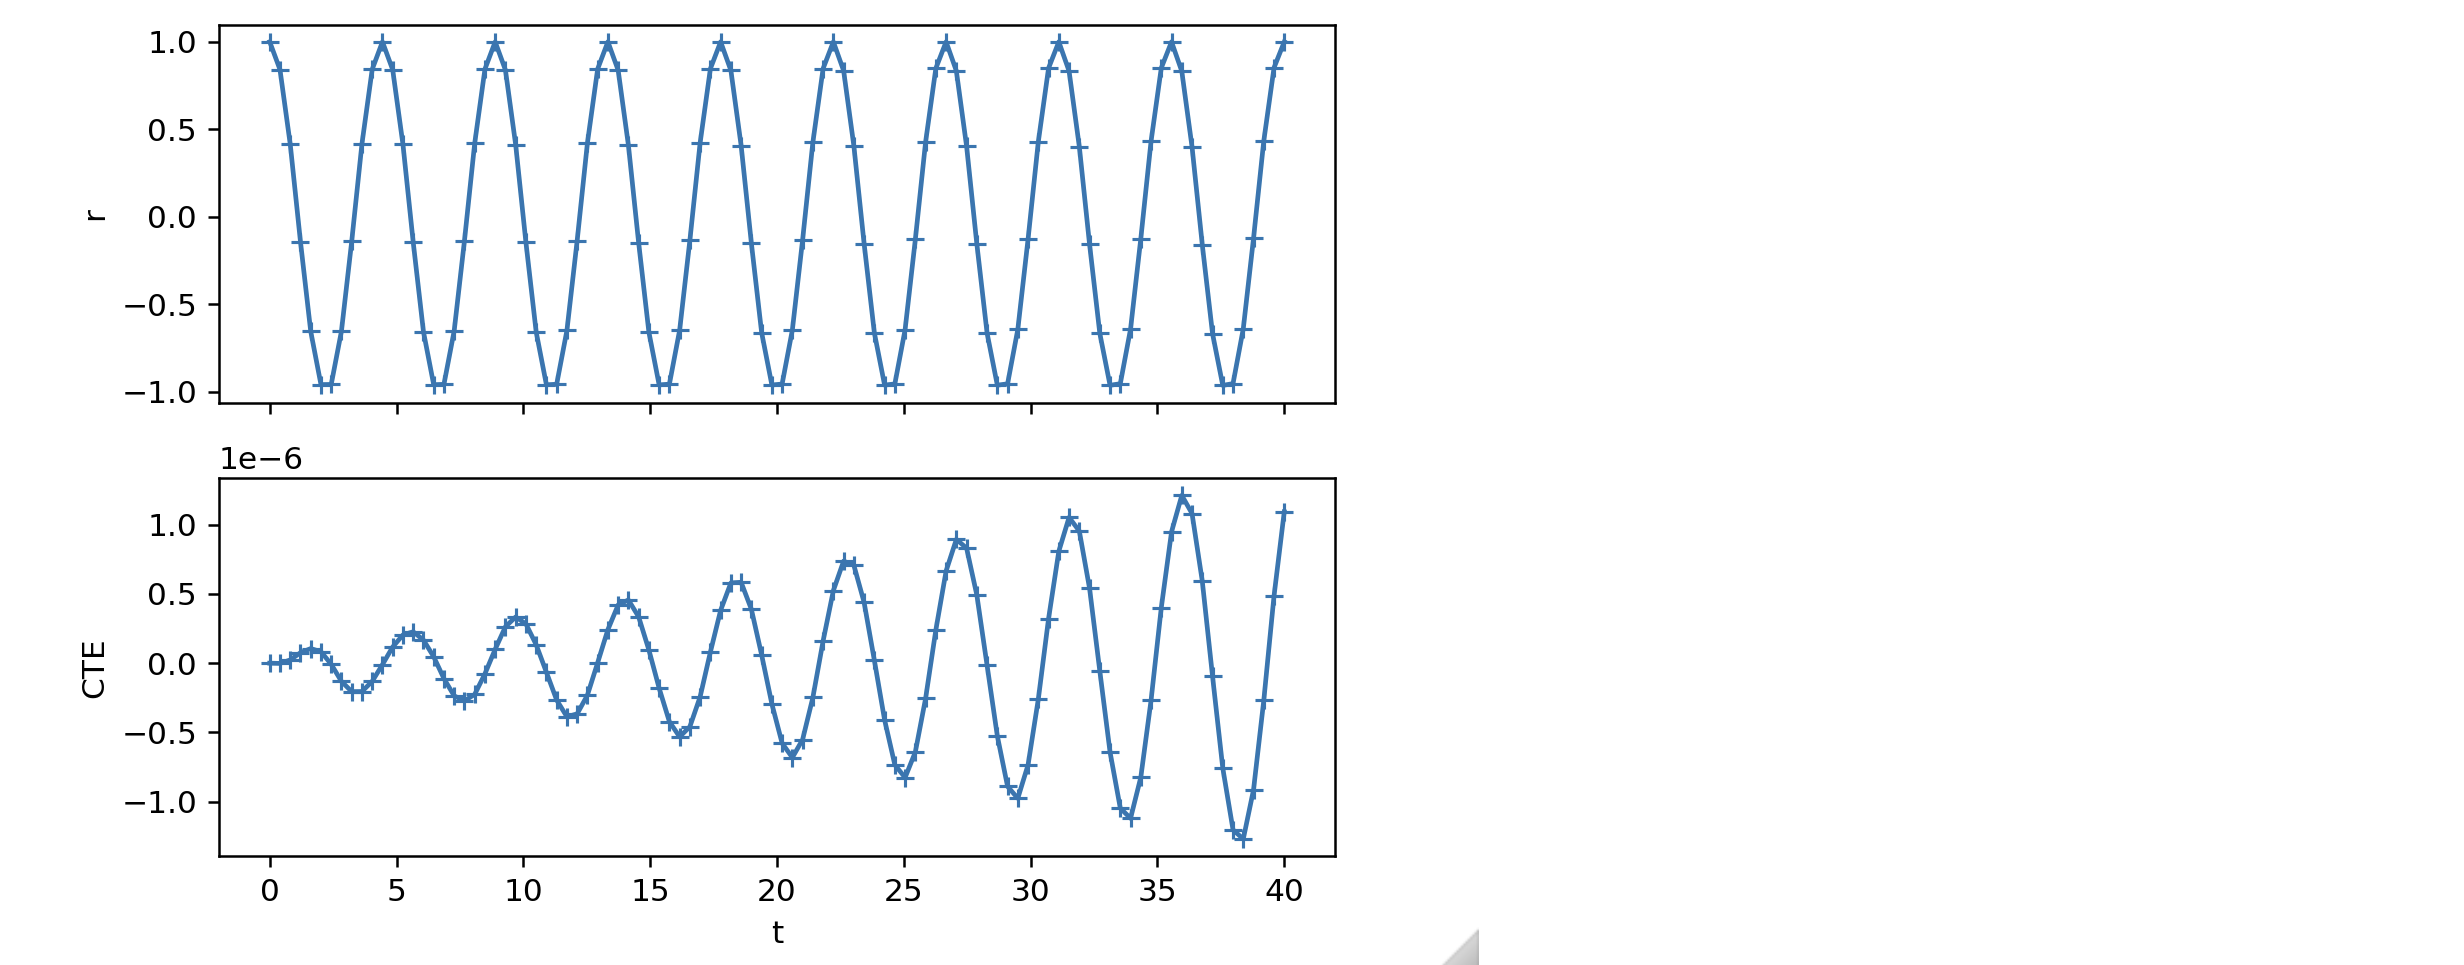

In [ ]:
# 无阻尼自由振动微分方程组
def dy_dt_simple(y, t):
    m = 1
    k = 2
    C = 0
    r, v = y
    f = 0
    drdt = v
    dvdt = (f - C*v - k*r) / m
    return [drdt, dvdt]

# 时间与初值
t3 = np.linspace(0, 40, 100)
y0_simple = [1, 0]

# 数值求解
sol_num = odeint(dy_dt_simple, y0_simple, t3)
r_numerical = sol_num[:, 0]

# 计算解析精确解
k = 2
m = 1
omega = np.sqrt(k / m)
r_analytical = np.cos(omega * t3)

# 计算累积整体误差CTE
CTE_error = r_numerical - r_analytical

# 双图绘制：位移对比 + 误差变化
plt.figure(figsize=(10, 7))
# 上图：数值解vs解析解
plt.subplot(2, 1, 1)
plt.plot(t3, r_numerical, marker='+', color='#1f77b4')
plt.plot(t3, r_analytical, '--')
plt.ylabel('r')
plt.legend()
plt.grid(True)


# 下图：累积误差随时间变化
plt.subplot(2, 1, 2)
plt.plot(t3, CTE_error, color='red', label='CTE')
plt.xlabel('t')
plt.ylabel('error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 利用quad构建类似odeint的求解函数

常微分方程$y(t_{n+1}) = y(t_n) + \int_{t_n}^{t_{n+1}} {y'(t) d t}$的数值积分部分可以用`scipy.integrate.quad`实现。
                                                  
构建一个`odeint_quad`函数，实现类似`scipy.integrate.odeint`的功能。函数包含`func, y0, t, args`四个参数，并利用循环+`quad`实现常微分方程求解。

对练习题1中的一阶一维常微分方程，利用`odeint_quad`求解，并与`scipy.integrate.odeint`的结果画图对比。

参考结果：

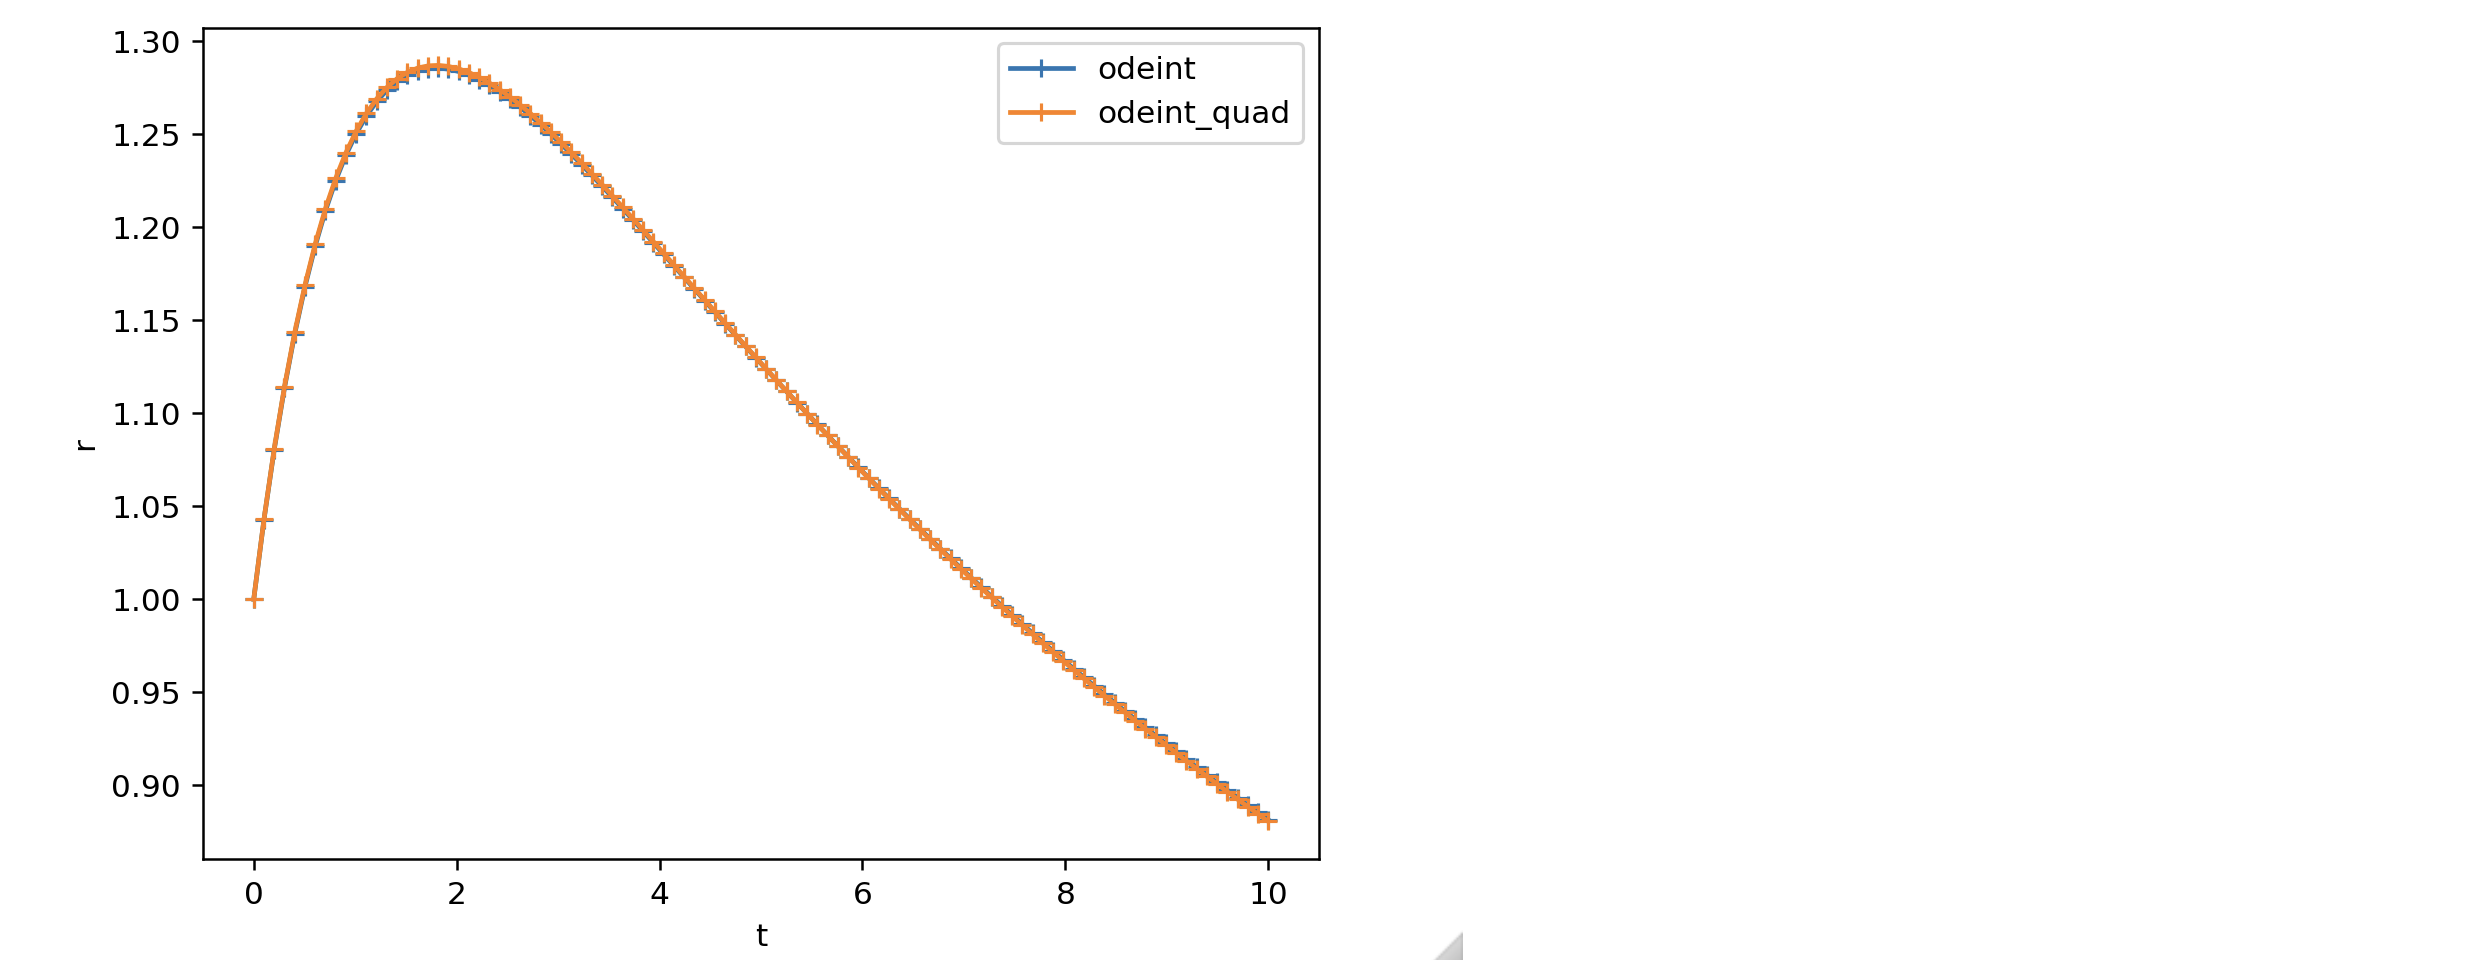

#### About `lambda` function




##### 一、`lambda` 的本质：现场造一个一次性函数

1.1 与 `def` 的对比

| 方式 | 写法 | 特点 |
|:---|:---|:---|
| `def` | `def f(x): return x+1` | 正式定义，有名字，可复用 |
| `lambda` | `lambda x: x+1` | 匿名，当场造，用完即走 |

```python
# 这两件事完全等价
def add_one(x):
    return x + 1

add_one = lambda x: x + 1

print(add_one(5))  # 都是 6
```

**`lambda` 的语法骨架：**

```python
lambda 参数1, 参数2, ... : 返回值表达式
```

它只能写**一个表达式**，不能写多行语句。



##### 二、为什么 `quad` 必须要你“现场造函数”？

这是理解你代码的关键。`scipy.integrate.quad` 的调用规则是：

```python
quad(f, a, b)
```

它要求 `f` 必须是**只有一个参数**的函数，这个参数就是积分变量（时间 `t`）。

但你的 ODE 右端函数签名是：

```python
func(y, t, *args)  # 需要 y, t, 还有额外参数
```

**矛盾来了：** `quad` 只想问“`f(t)` 是多少？”，但你的函数回答的是“我需要知道 `y` 和 `args` 才能告诉你”。

所以你需要**现场做一个新函数**：把 `y` 和 `args` 固定死，只留下 `t` 作为唯一变量，交给 `quad`。


##### 三、在你的代码里具体发生了什么？

假设当前这一步：

```python
ylast = 2.0          # 上一步算出来的 y 值
args = (0.5, 1.2)    # func 需要的额外参数
tstart = 0.0
tend = 1.0
```

你的 `func` 可能是这样的（举个例子）：

```python
def func(y, t, k, m):
    return -k * y + m * np.sin(t)
```

3.1 如果不写 lambda，直接传 `func` 会怎样？

```python
quad(func, tstart, tend)  # ❌ 报错
```

`quad` 内部会尝试调用 `func(某个时间点)`，只传一个参数。但 `func` 定义了三个参数（`y, t, k, m`），Python 会立刻抛出 `TypeError: func() missing 3 required positional arguments...`。

3.2 lambda 做了什么？

```python
quad_func = lambda t: func(ylast, t, *args)
```

**逐字拆解：**

```python
quad_func = lambda t: func(2.0, t, 0.5, 1.2)
```

- `lambda t:` → 告诉 Python：“我要造一个函数，它只有一个入口 `t`”
- `func(2.0, t, 0.5, 1.2)` → 这个函数内部做的事：把 `ylast=2.0` 和 `args` 填进去，再把外部传入的 `t` 塞到第二个位置。

3.3 代入数值看效果

`quad` 内部会自动选很多采样点，比如它第一次想算 `t = 0.2` 处的被积函数值：

```python
# quad 内部等价于这样调用：
value = quad_func(0.2)
# 即：
value = func(2.0, 0.2, 0.5, 1.2)
# 返回：-0.5 * 2.0 + 1.2 * sin(0.2)
```

第二次想算 `t = 0.7`：

```python
value = quad_func(0.7)
# 即：
value = func(2.0, 0.7, 0.5, 1.2)
```

**注意：** 在整个区间 `[0.0, 1.0]` 的积分过程中，`ylast` 始终是 `2.0`，不会变。`quad` 只是不断地换 `t` 的值来采样。这就是你注释里写的：

> “近似假设 y 在 func 积分过程中不变，始终为前一步的值 ylast”

---



这就是 `lambda` 在此处的唯一目的：**参数适配**——把多变量函数 `func(y, t, *args)` 包装成单变量函数 `f(t)`，同时把当前步的 `y` 冻结住。

In [ ]:
def odeint_quad(func, y0, t, args=()):
    # 初始化结果数组
    y_result = np.zeros_like(t)
    y_result[0] = y0
    # 逐时间步循环积分
    for i in range(len(t) - 1):
        t_start = t[i]
        t_end = t[i + 1]
        y_current = y_result[i]
        # quad计算区间导数积分
        integral_val, _ = quad(lambda tau: func(y_current, tau, *args), t_start, t_end)
        y_result[i + 1] = y_current + integral_val
    return y_result.reshape(-1, 1)

# ========== 习题1一阶阻尼推力方程测试 ==========
def dv_dt(v, t):
    m = 2
    C = 0.1
    f_t = np.exp(-t)
    return (f_t - C * v ** 2) / m

# 题目给定时间、初值
t = np.linspace(0, 10, 100)
v0 = 1

# 分别用原生odeint、自定义odeint_quad求解
v_standard = odeint(dv_dt, v0, t)
v_custom_quad = odeint_quad(dv_dt, v0, t)

# 对比绘图（无中文标签）
plt.figure(figsize=(8, 5))
plt.plot(t, v_standard, label="odeint", color="#1f77b4", marker="+")
plt.plot(t, v_custom_quad, label="odeint_quad", color="#ff7f0e", marker="+")
plt.xlabel("t")
plt.ylabel("v")
plt.legend()
plt.grid(True)
plt.show()

## 实现常微分方程求解算法——欧拉法

欧拉法的积分公式为：$\mathbf{y}_{i+1} = \mathbf{y}_i + h f(t_i, \mathbf{y}_i)$，利用上题中基于`quad`函数实现的常微分方程求解函数`odeint_quad`的框架，将其中quad积分替换为欧拉法的积分公式，实现基于欧拉法的新求解函数`odeint_euler`

## 分析欧拉法局部误差与累积误差对步长依赖

基于练习题3误差分析中求解的简谐振动常微分方程，利用不同的时间步长$h$，用`odeint_euler`实现求解，并通过对比解析解，绘制局部近似误差LTE与累积近似误差CTE对步长h的依赖关系。

提示：
- 不同时间步长$h$可以通过设置时间点数组t的取点个数来调控。例：t从范围0到1间，分别取等间隔100,1000,10000,100000个点，带入`odeint_euler`求解。
- 局部近似误差LTE可以由第一步求解$y(t_1)$值与精确解$y_r(t_1)$的差取绝对值计算得到：LTE = $|y(t_1)-y_r(t_1)|$。
- 累积近似误差CTE可以由最后一步求解值$y(t_n)$与精确解的差，取绝对值计算得到：CTE = $|y(t_n)-y_r(t_n)|$。

参考结果：
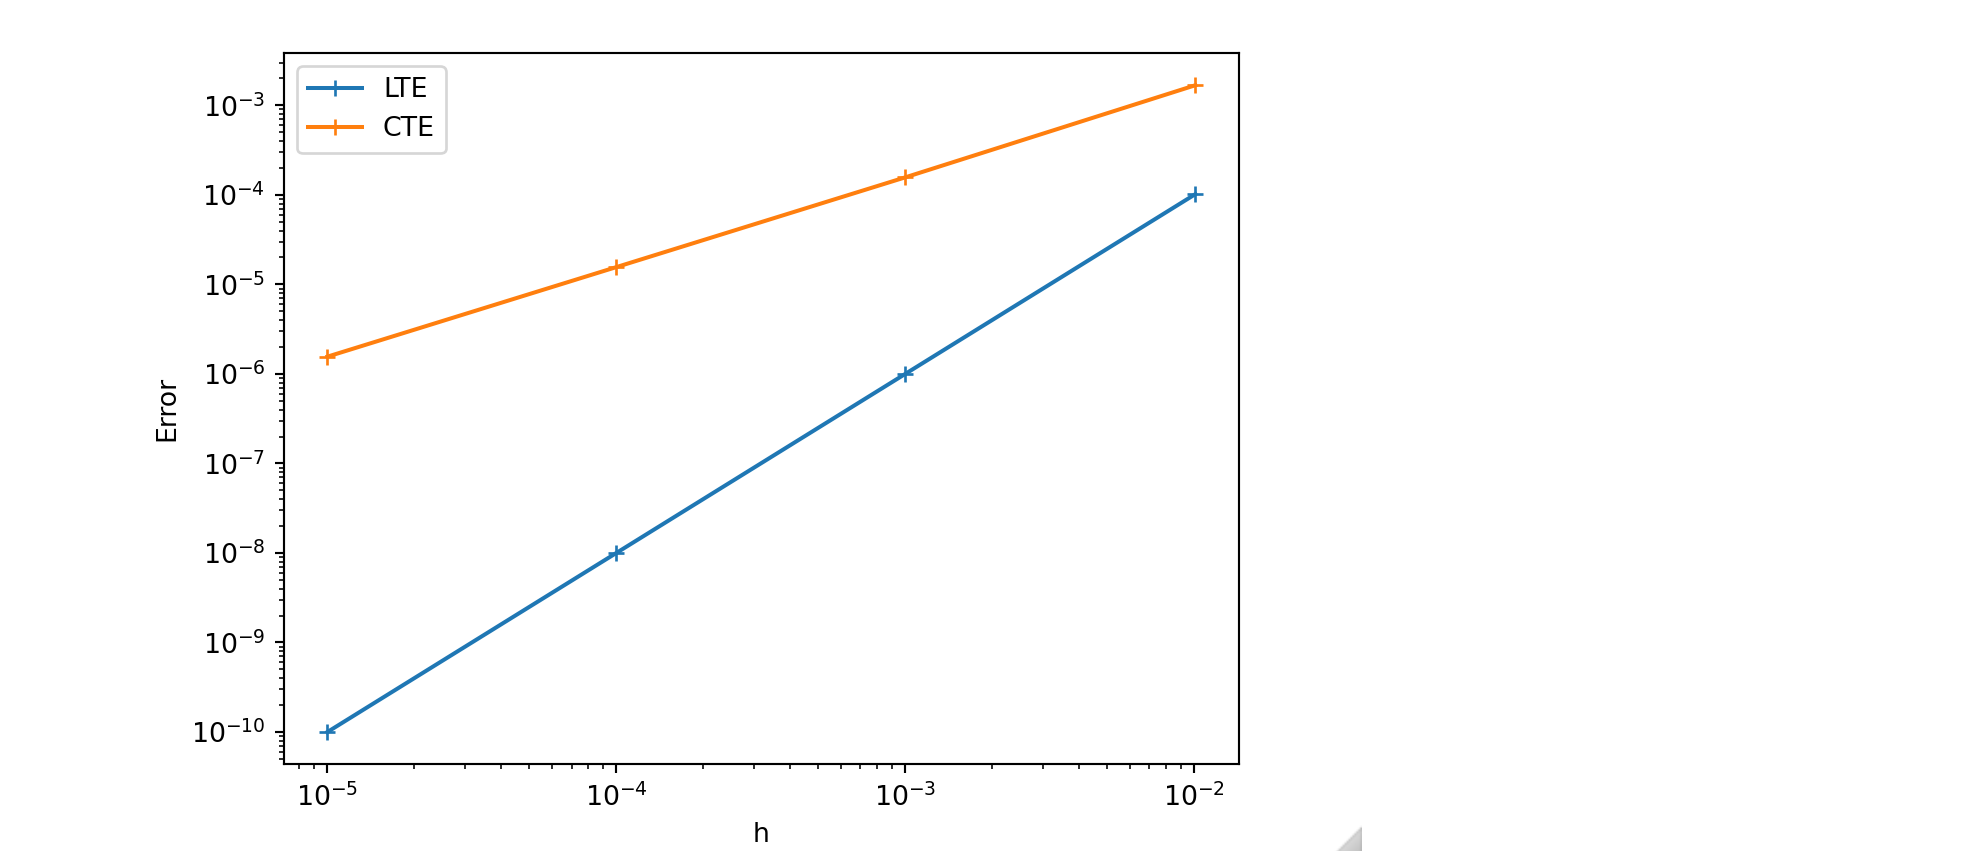

从LTE与h的关系图可以看到，表明欧拉法只有2阶精度


In [ ]:
import numpy as np
from scipy.integrate import odeint, quad
import matplotlib.pyplot as plt

# ===================== 1. 自定义quad积分求解器 =====================
def odeint_quad(func, y0, t, args=()):
    y_result = np.zeros_like(t)
    y_result[0] = y0
    for i in range(len(t) - 1):
        t_start, t_end = t[i], t[i+1]
        y_current = y_result[i]
        integral_val, _ = quad(lambda tau: func(y_current, tau, *args), t_start, t_end)
        y_result[i+1] = y_current + integral_val
    return y_result.reshape(-1, 1)

# 测试方程
def dv_dt(v, t):
    m = 2
    C = 0.1
    f_t = np.exp(-t)
    return (f_t - C * v ** 2) / m

t = np.linspace(0, 10, 100)
v0 = 1
v_standard = odeint(dv_dt, v0, t)
v_custom_quad = odeint_quad(dv_dt, v0, t)

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(t, v_standard, label="odeint", marker="+")
plt.plot(t, v_custom_quad, label="odeint_quad", marker="+")
plt.xlabel("t")
plt.ylabel("v")
plt.legend()
plt.grid(True)
plt.show()

# ===================== 2. 欧拉法（修复核心报错） =====================
def odeint_euler(func, y0, t, args=()):
    state_dim = len(np.atleast_1d(y0))
    y_result = np.zeros((len(t), state_dim))
    y_result[0] = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        t_now = t[i]
        y_now = y_result[i]
        # 修复：列表转numpy数组，支持数值运算
        dy_dt = np.array(func(y_now, t_now, *args))
        y_result[i+1] = y_now + h * dy_dt
    return y_result

# 简谐振动方程
m, k = 1, 2
def dy_dt_harmonic(y, t):
    r, v = y
    drdt = v
    dvdt = -k / m * r
    return [drdt, dvdt]

# 解析解
def r_analytical(t):
    omega = np.sqrt(k / m)
    return np.cos(omega * t)

# 误差分析
point_num_list = [100, 1000, 10000, 100000]
step_h_list, LTE_error_list, CTE_error_list = [], [], []

for n_point in point_num_list:
    t = np.linspace(0, 40, n_point)
    h = t[1] - t[0]
    step_h_list.append(h)
    
    sol_euler = odeint_euler(dy_dt_harmonic, [1, 0], t)
    r_euler = sol_euler[:, 0]
    
    LTE = abs(r_euler[1] - r_analytical(t[1]))
    CTE = abs(r_euler[-1] - r_analytical(t[-1]))
    LTE_error_list.append(LTE)
    CTE_error_list.append(CTE)

# 绘图
plt.figure(figsize=(8, 5))
plt.loglog(step_h_list, LTE_error_list, label="LTE", marker="+")
plt.loglog(step_h_list, CTE_error_list, label="CTE", marker="+")
plt.xlabel("Step h")
plt.ylabel("Error")
plt.legend()
plt.grid(True, which="both")
plt.show()

## 实现常微分方程求解算法——龙格库塔法

以之前实现的欧拉求解方法`odeint_euler`为参照，实现4阶龙格库塔法函数`odeint_rk4`，输入参数与返回结果保持一致。

提示：用以下龙格库塔法的积分公式，替换`odeint_euler`欧拉法的积分公式，实现`odeint_rk4`
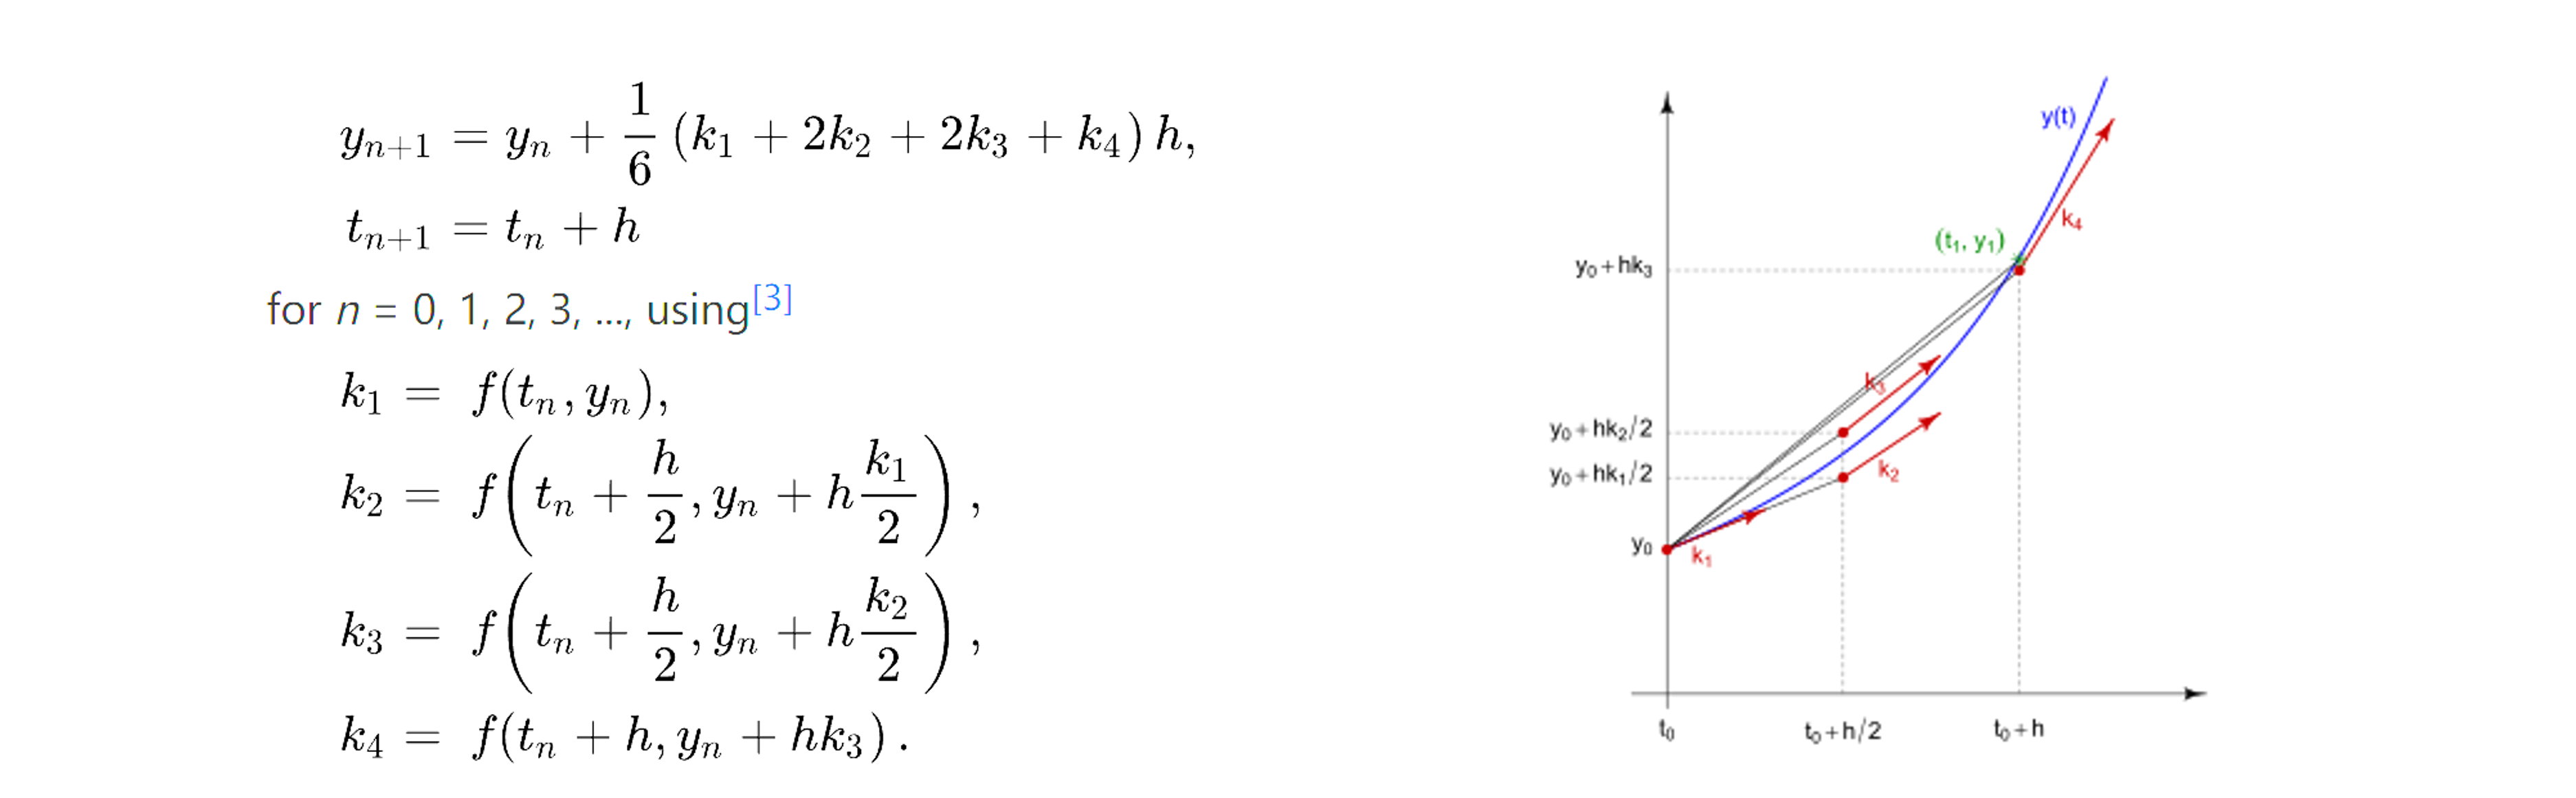


In [ ]:
def odeint_rk4(func, y0, t, args=()):
    state_dim = len(np.atleast_1d(y0))
    y_result = np.zeros((len(t), state_dim))
    y_result[0] = y0
    
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        t_n = t[i]
        y_n = y_result[i]
        
        # 修复：所有斜率转numpy数组
        k1 = np.array(func(y_n, t_n, *args))
        k2 = np.array(func(y_n + h * k1 / 2, t_n + h/2, *args))
        k3 = np.array(func(y_n + h * k2 / 2, t_n + h/2, *args))
        k4 = np.array(func(y_n + h * k3, t_n + h, *args))
        
        y_result[i+1] = y_n + h * (k1 + 2*k2 + 2*k3 + k4) / 6
    return y_result

# RK4测试
t_rk = np.linspace(0, 40, 100)
sol_rk4 = odeint_rk4(dy_dt_harmonic, [1, 0], t_rk)
r_rk4 = sol_rk4[:, 0]
r_true = r_analytical(t_rk)

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(t_rk, r_rk4, label="RK4 Numerical")
plt.plot(t_rk, r_true, label="Analytical Solution", linestyle="--")
plt.xlabel("t")
plt.ylabel("r")
plt.legend()
plt.grid(True)
plt.show()

## 分析龙格库塔法的局部近似误差对步长的依赖

类似1.6题中分析欧拉法的局部近似误差对步长的依赖，对4阶龙格库塔法进行分析。
提示：
- 分析欧拉法时使用的步长较小，对应步长$h = 10^{-2}, 10^{-3}, 10^{-4}$和$10^{-5}$。但对4阶龙格库塔法，相同的步长设置会发现局部近似误差不再和h呈现5次关系，原因是什么？
- 为得到正确的误差与步长关系，建议用更大的步长：$h = 10, 1, 10^{-1}, 10^{-2}$测试。

参考结果：

从图中可见，当步长h减小10倍，误差减小近$10^5$倍，甚至更好。
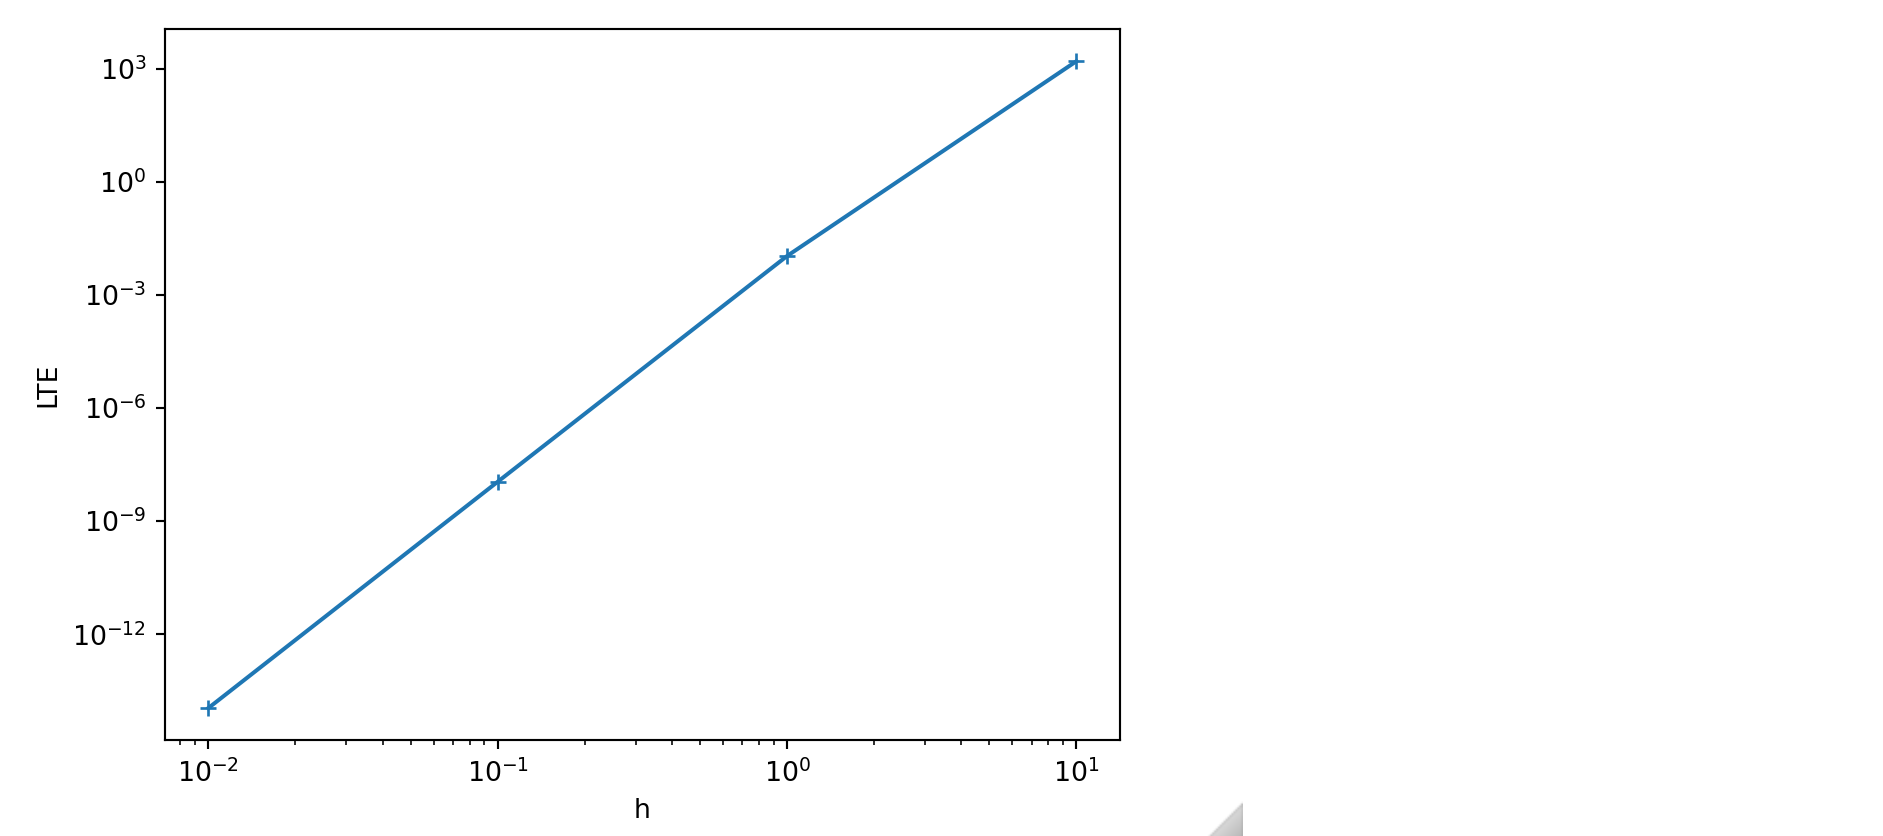

In [ ]:
def odeint_rk4(func, y0, t, args=()):
    state_dim = len(np.atleast_1d(y0))
    y_result = np.zeros((len(t), state_dim))
    y_result[0] = y0
    
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        t_n = t[i]
        y_n = y_result[i]
        
        # 强制列表转numpy数组，避免运算报错
        k1 = np.array(func(y_n, t_n, *args))
        k2 = np.array(func(y_n + h * k1 / 2, t_n + h/2, *args))
        k3 = np.array(func(y_n + h * k2 / 2, t_n + h/2, *args))
        k4 = np.array(func(y_n + h * k3, t_n + h, *args))
        
        y_result[i+1] = y_n + h * (k1 + 2*k2 + 2*k3 + k4) / 6
    return y_result

# 简谐振动微分方程（二阶转一阶）
m, k = 1, 2
def dy_dt_harmonic(y, t):
    r, v = y
    drdt = v
    dvdt = -k / m * r
    return [drdt, dvdt]

# 简谐振动解析精确解
def r_analytical(t):
    omega = np.sqrt(k / m)
    return np.cos(omega * t)
# 题目要求的步长列表
h_list = [10, 1, 0.1, 0.01]
LTE_list = []

for h in h_list:
    # 仅计算单步：0 → h，求解局部误差LTE
    t = np.array([0, h])
    y0 = [1, 0]
    sol_rk = odeint_rk4(dy_dt_harmonic, y0, t)
    r_num = sol_rk[1, 0]
    r_true = r_analytical(h)
    LTE = np.abs(r_num - r_true)
    LTE_list.append(LTE)

# 双对数坐标绘图（无任何中文）
plt.figure(figsize=(8, 6))
plt.loglog(h_list, LTE_list, color='#1f77b4', marker='+')
plt.xlabel("Step h")
plt.ylabel("LTE")
plt.grid(True, which="both")
plt.show()

## (选作）时间反演对称性

对一个常微分方程，当从初始条件$y(t_0)$求解$y(t_1), y(t_2),...,y(t_n)$后，如果反向求解，以$y(t_n)$为初始条件，使用负时间步长求解得到$\bar{y}(t_{n-1}), \bar{y}(t_{n-2}), ..., \bar{y}(t_0)$。$y(t_i)$与$\bar{y}(t_i)$能否重合？

如果算法能够保证正反两次求解的差异与局部近似误差在相近水平，则该算法具有时间反演对称性，适合处理具有周期解的常微分方程问题。

我们可以考察scipy的`odeint`是否具有这个特性：对1.2题中的弹簧振动问题，实现正向求解后，再反向求解，计算反向与正向求解结果的差异，画图分析。

参考结果：

从结果可以看出，反向求解的结果在$t_0$附近有$10^{-3}$量级的差异，远大于局部近似误差$10^{-8}$的量级，因此，在这个问题中，`odeint`的求解结果不具备时间反演对称性
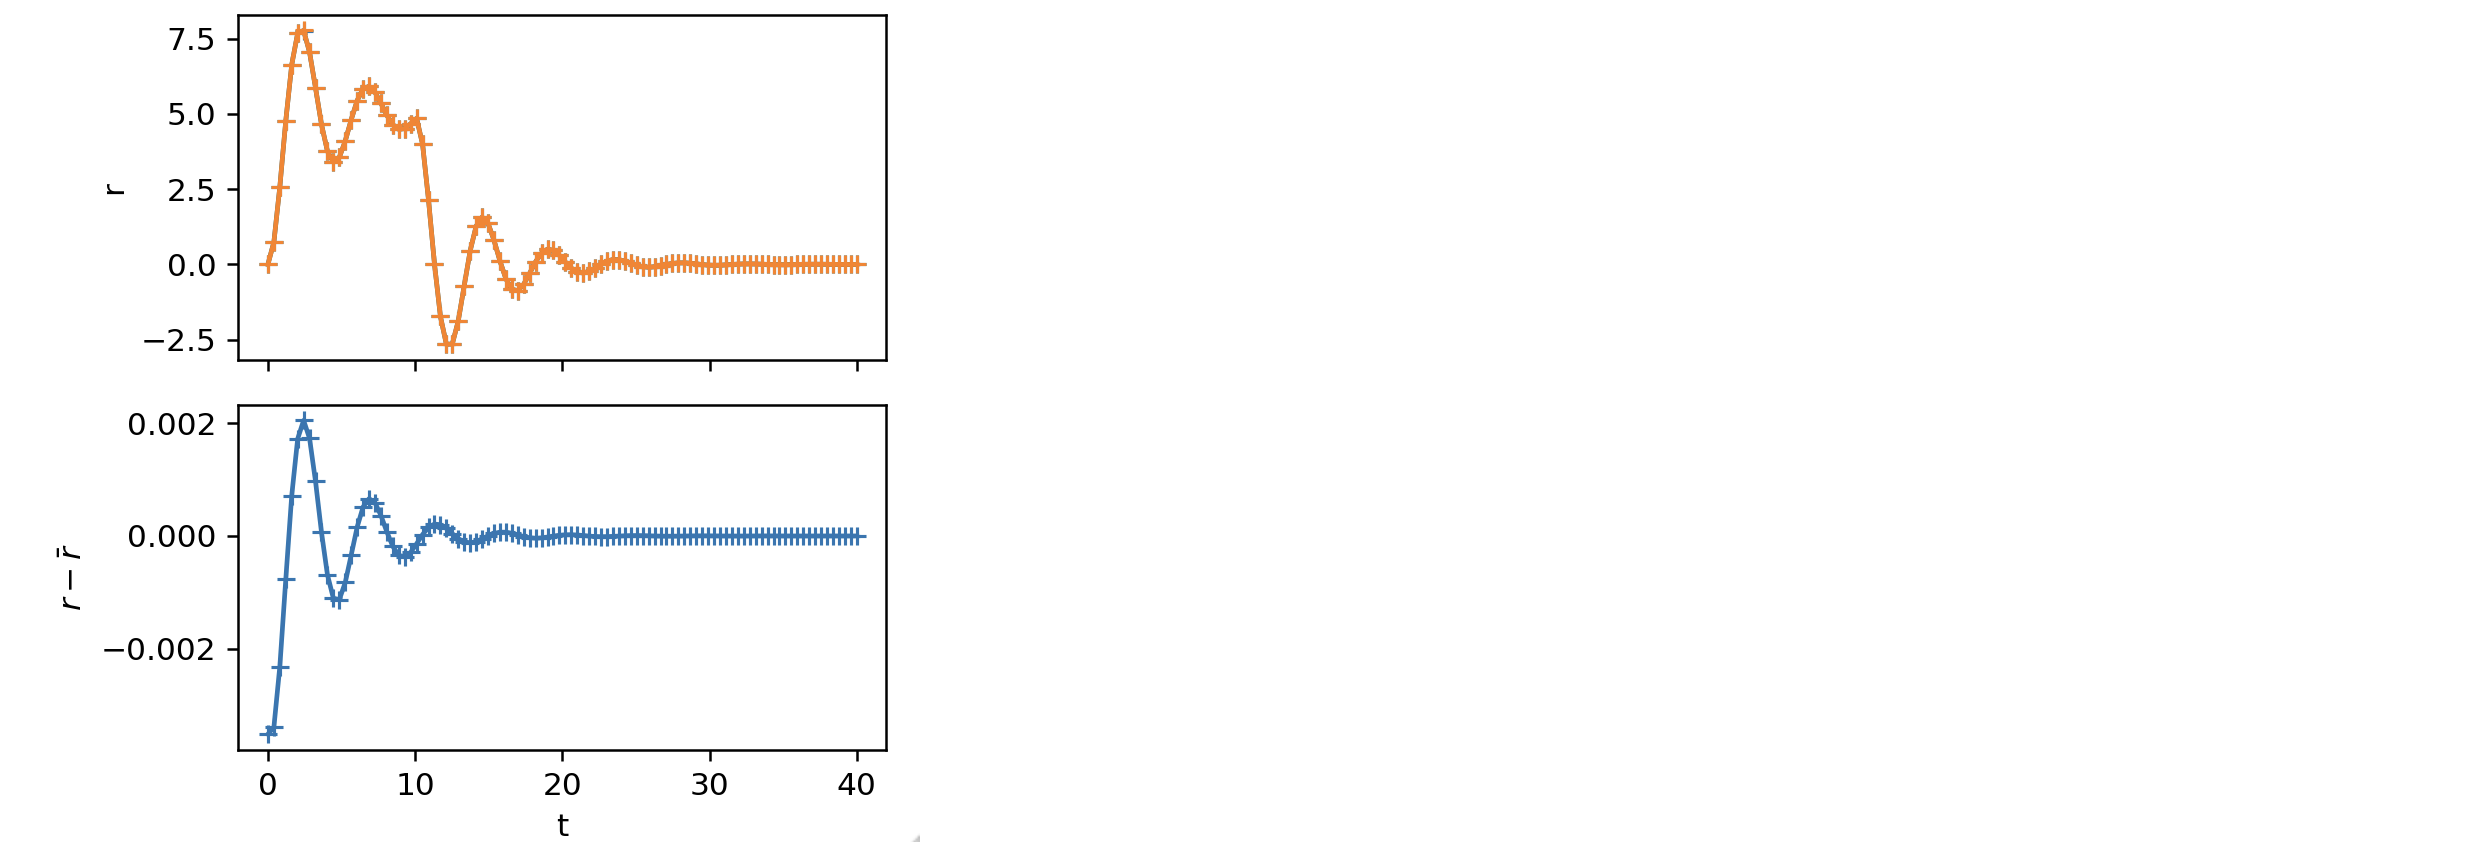

In [ ]:
# 弹簧振动微分方程（分段外力）
def dy_dt_spring(y, t):
    m = 1
    C = 0.5
    k = 2
    b = 10
    r, v = y
    # 分段外力
    if t < 10:
        f = b
    else:
        f = 0
    drdt = v
    dvdt = (f - C*v - k*r) / m
    return [drdt, dvdt]

# 1. 正向求解：0 → 40
t_forward = np.linspace(0, 40, 100)
y0_forward = [0, 0]
sol_forward = odeint(dy_dt_spring, y0_forward, t_forward)
r_forward = sol_forward[:, 0]

# 2. 反向求解：40 → 0，以正向终点为初始条件
t_backward = np.linspace(40, 0, 100)
y0_backward = sol_forward[-1]
sol_backward = odeint(dy_dt_spring, y0_backward, t_backward)
# 逆序对齐正向时间轴
r_backward = sol_backward[::-1, 0]

# 计算正反解差值
diff = r_forward - r_backward

# 上下双图绘图（无中文，匹配参考样式）
plt.figure(figsize=(8, 8))
# 上图：正反位移对比
plt.subplot(2,1,1)
plt.plot(t_forward, r_forward, label="Forward", color='#ff7f0e')
plt.ylabel("r")
plt.legend()
plt.grid(True)

# 下图：正反解误差差值
plt.subplot(2,1,2)
plt.plot(t_forward, diff, color='#1f77b4')
plt.xlabel("t")
plt.ylabel("r-r̃")
plt.grid(True)

plt.tight_layout()
plt.show()

## （选作）混沌三体问题

参考课件N-body_ODE.ipynb，利用常微分方程求解算法，求解引力作用下的混沌三体系统的轨迹。

提示：
- N个天体受引力相互作用，第$i$个天体的位置矢量$r_i$随时间的变化可以由3N维2阶的常微分方程组描述，引入速度矢量$v_i$后，可以转换为6N维1阶常微分方程组。其中，第$i$个粒子的方程可以表示为：

    - $ x'_i = v_{x,i} $
    - $ y'_i = v_{y,i} $
    - $ z'_i = v_{z,i} $
    - $ v_{x,i}' =  \sum_{j=1}^N {\frac{G m_j (x_j-x_i)}{\left|\mathbf{r}_j - \mathbf{r}_i \right|^3}} $
    - $ v_{y,i}' =  \sum_{j=1}^N {\frac{G m_j (y_j-y_i)}{\left|\mathbf{r}_j - \mathbf{r}_i \right|^3}} $
    - $ v_{z,i}' =  \sum_{j=1}^N {\frac{G m_j (z_j-z_i)}{\left|\mathbf{r}_j - \mathbf{r}_i \right|^3}} $

- 利用`odeint`实现上面的常微分方程函数并求解三体系统的运动轨迹。

- 其中:

    - 三体的初始条件如下图所示，处于x-y平面内直角三角形的三个顶点处，三边长比值为3:4:5。天体的初速度都为0，假定G=1，天体质量都为1（忽略单位）

    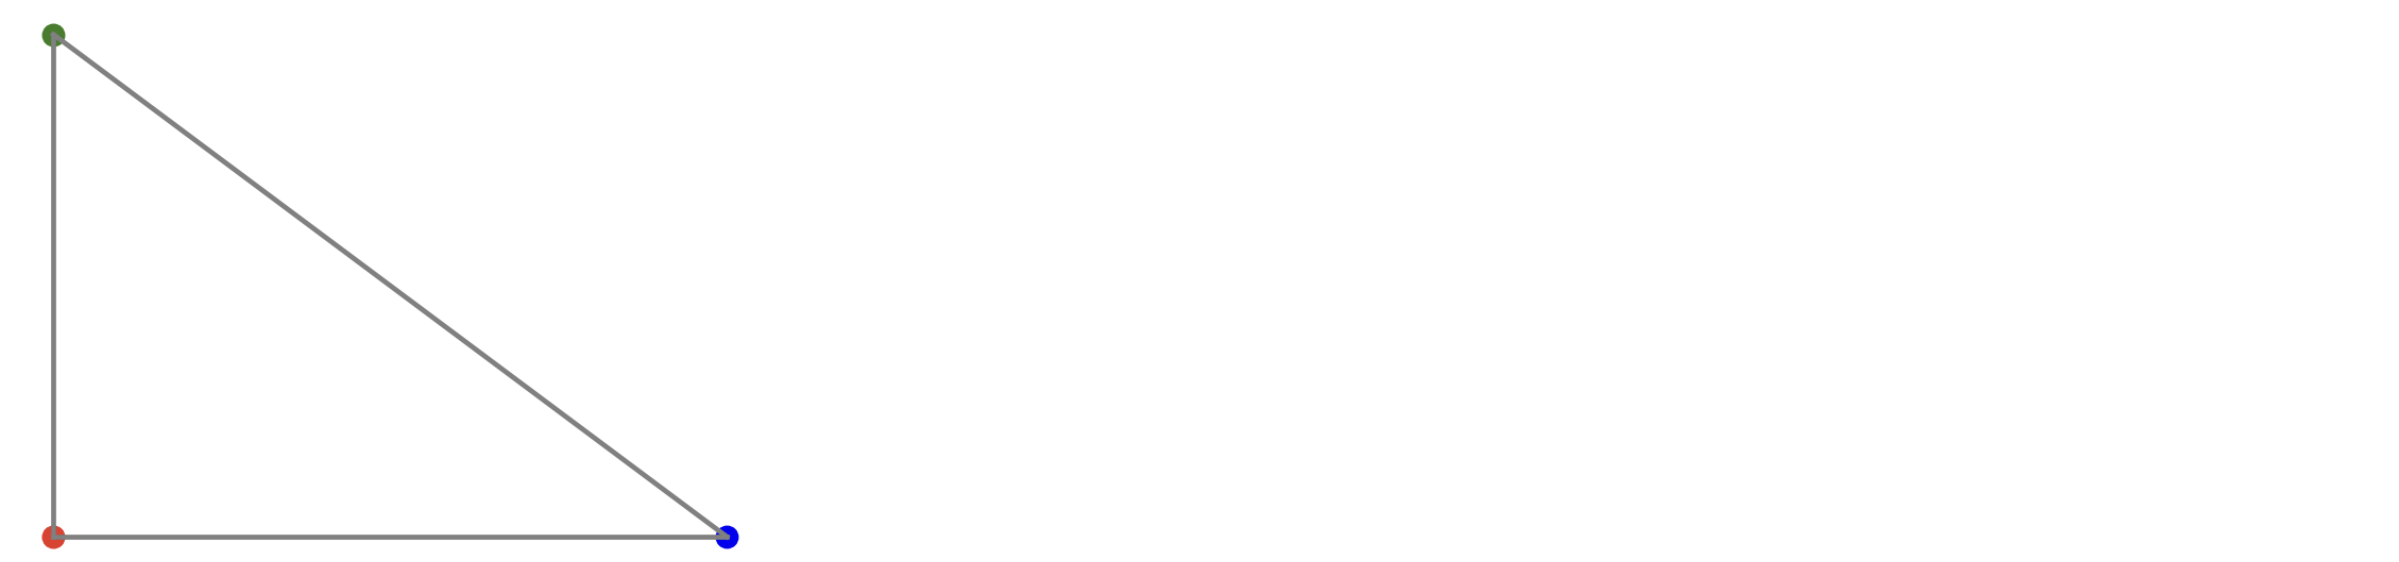

    - 时间点从0取到100，共20000个点。

参考结果：

绘制三体的运动轨迹图,得到如下所示结果。时间点间隔不一样后，如从20000变为40000，运动轨迹是否相同？
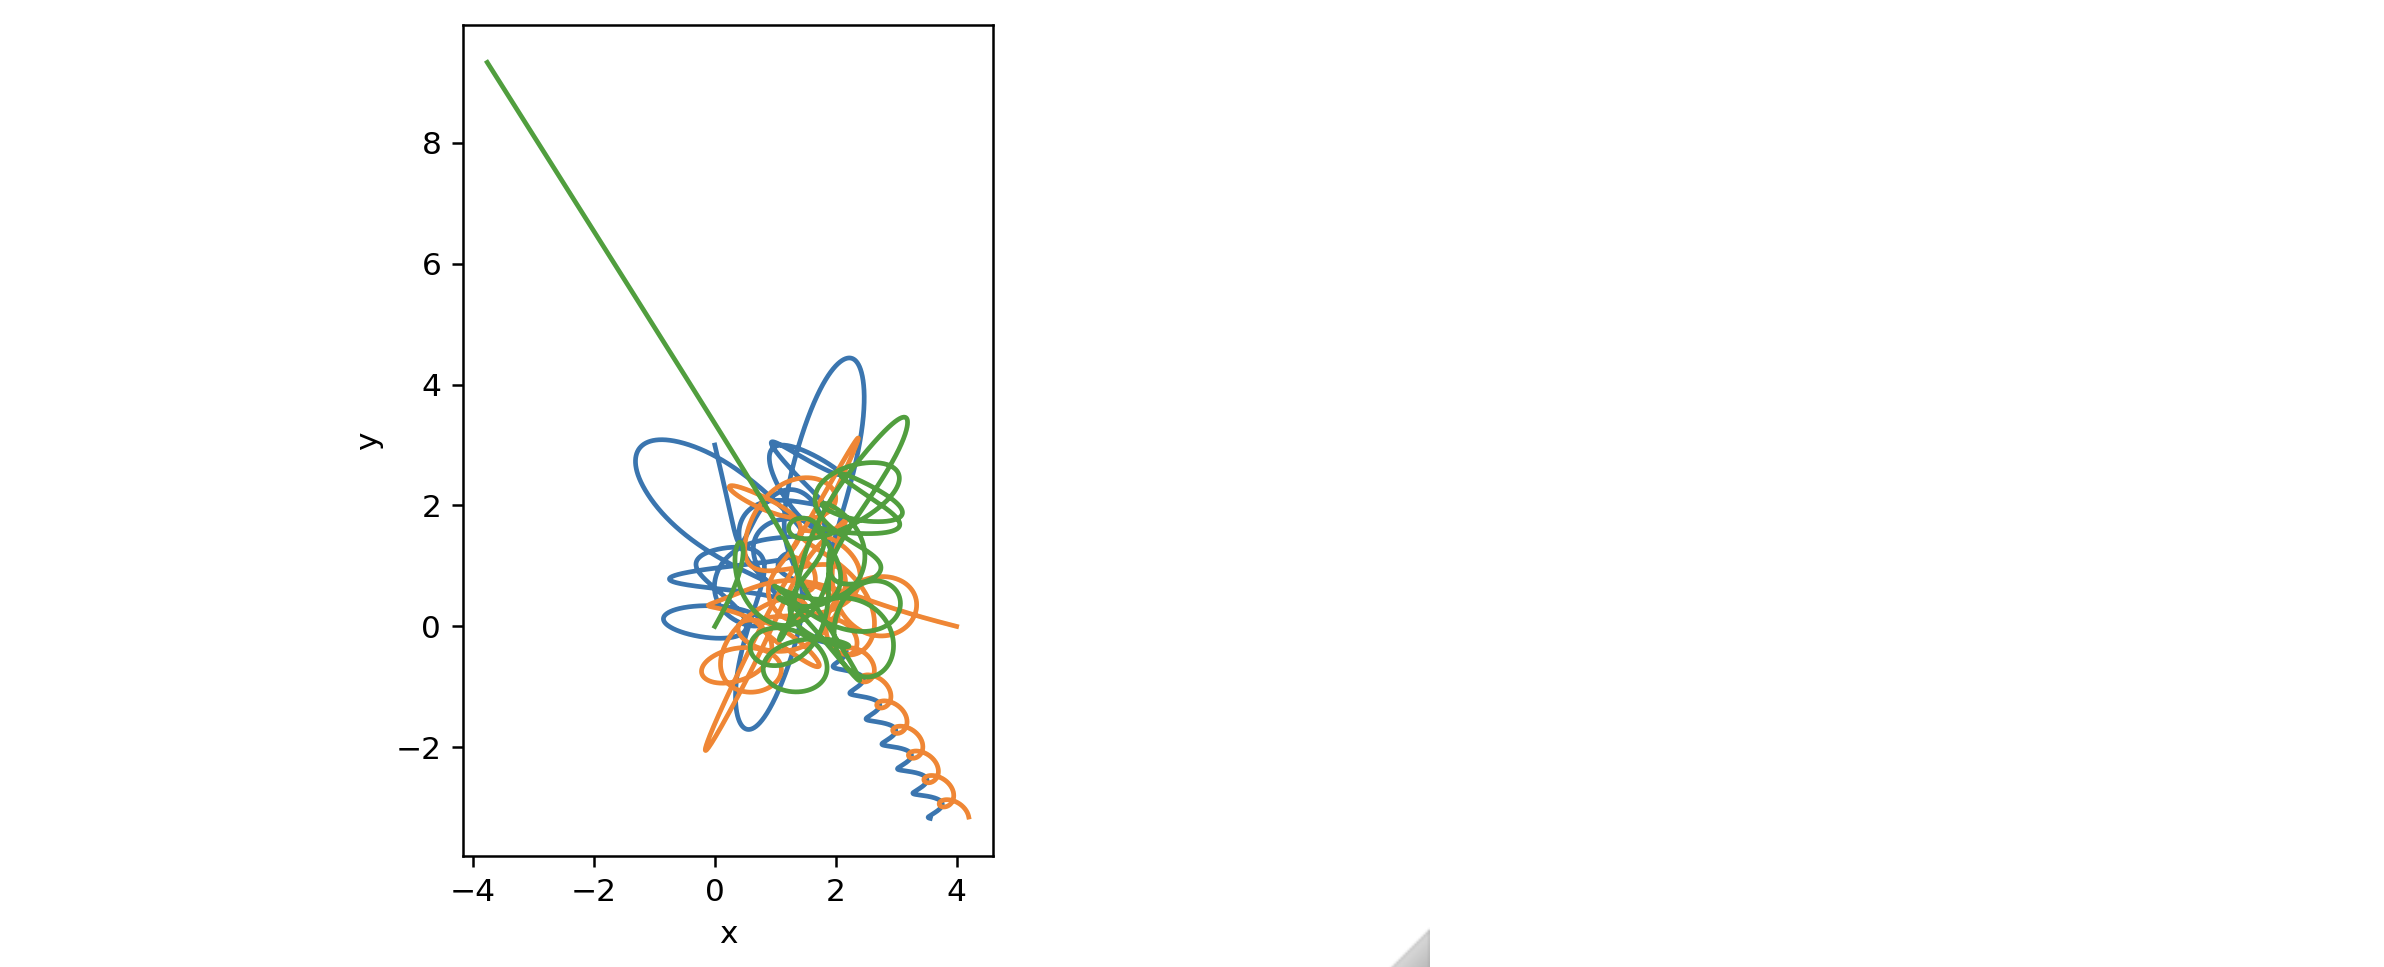

In [ ]:
G = 1
m = [1, 1, 1]  # 三个天体质量

# 三体ODE方程组：6N=18维一阶微分方程
def three_body_ode(state, t):
    # 状态顺序：x1,y1,z1,vx1,vy1,vz1, x2,y2,z2,vx2,vy2,vz2, x3,y3,z3,vx3,vy3,vz3
    x1,y1,z1,vx1,vy1,vz1, x2,y2,z2,vx2,vy2,vz2, x3,y3,z3,vx3,vy3,vz3 = state
    
    # 两两引力距离计算
    r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2)
    r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2 + (z3-z1)**2)
    r23 = np.sqrt((x3-x2)**2 + (y3-y2)**2 + (z3-z2)**2)
    
    # 天体1加速度
    a1x = G*m[1]*(x2-x1)/r12**3 + G*m[2]*(x3-x1)/r13**3
    a1y = G*m[1]*(y2-y1)/r12**3 + G*m[2]*(y3-y1)/r13**3
    a1z = G*m[1]*(z2-z1)/r12**3 + G*m[2]*(z3-z1)/r13**3
    
    # 天体2加速度
    a2x = G*m[0]*(x1-x2)/r12**3 + G*m[2]*(x3-x2)/r23**3
    a2y = G*m[0]*(y1-y2)/r12**3 + G*m[2]*(y3-y2)/r23**3
    a2z = G*m[0]*(z1-z2)/r12**3 + G*m[2]*(z3-z2)/r23**3
    
    # 天体3加速度
    a3x = G*m[0]*(x1-x3)/r13**3 + G*m[1]*(x2-x3)/r23**3
    a3y = G*m[0]*(y1-y3)/r13**3 + G*m[1]*(y2-y3)/r23**3
    a3z = G*m[0]*(z1-z3)/r13**3 + G*m[1]*(z2-z3)/r23**3

    return [vx1,vy1,vz1, a1x,a1y,a1z,
            vx2,vy2,vz2, a2x,a2y,a2z,
            vx3,vy3,vz3, a3x,a3y,a3z]

# 初始条件：位置+零初速度
y0 = [0,0,0, 0,0,0,
      0,3,0, 0,0,0,
      4,0,0, 0,0,0]

# 时间序列：0~100，20000个点
t = np.linspace(0, 100, 20000)

# 数值求解
sol = odeint(three_body_ode, y0, t)

# 绘制XY平面混沌轨迹（无中文）
plt.figure(figsize=(8,8))
plt.plot(sol[:,0], sol[:,1], label="Body1", color="red")
plt.plot(sol[:,6], sol[:,7], label="Body2", color="green")
plt.plot(sol[:,12], sol[:,13], label="Body3", color="blue")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

---
# 第二部分：偏微分方程求解练习

## 一维正弦波传递

利用中心差分方法求解一维正弦波从左向右传递的波动方程$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$ 
的解，即振动强度函数$u(t,x)$，对应离散化数值解$u^i_k$，其中：
- $c$ 为波速，
- $k$ 表征时间格点，
- $i$表征空间格点。

对应求解方法与条件：
- 中心差分方法迭代公式（中间格点）：
  
    $u_{k+1}^i = 2u_k^i - u_{k-1}^i + \frac{c^2 \Delta t^2}{\Delta x^2} \left( u_k^{i+1} - 2u_k^i + u_k^{i-1} \right)$
  
- 边界条件：
    - 左边界：正弦波发射器，满足$u^1(t) = \frac{v_{s}}{\omega} \sin{[\omega t]}$，其中$v_s$为边界格点的初始速度,我们设置为1， $\omega$决定角频率，设置为2。
    - 右边界：吸收边界条件，能将波动向外传递出去，可以使用以下公式：$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$。
            离散化后，右边界的值可以更新为：
            $u^N_{k+1} = u^N_k + \frac{c \Delta t}{\Delta x} \left( u^{N-1}_k - u^N_k   \right)$
- 初始条件：
    - 格点数N=100, $\Delta x = 2\pi/N$, $\Delta t = 2e-4$, $c=1$
    - t=0: $u_0^i$全为0
    - t=$-\Delta t$: $u^{1}_{-1} =  \frac{v_{s}}{\omega} \sin{[-\omega \Delta t]}$，其他都为0

请补充以下求解代码中的缺失部分（缺失部分由`...`表示)：
1. 补充中心差分的更新公式，由u0_pre 和 u0 计算出新的 u
2. 补充左边阶条件的实现

In [ ]:
# 初始条件
N = 100
x = np.linspace(0, 2*np.pi, N)
dx = x[1]-x[0]
dt = 2e-4

vs = 1
w = 2
c = 1

u0 = np.zeros(N)
u0_pre = np.zeros(N)
u0_pre[0] = vs/w*np.sin(-w*dt)

u = u0.copy()

ulist = [u.copy()]
tlist = [0]

nstep = 50000

for k in range(1,nstep+1):
    # # 在下面 补充中心差分的更新公式，由u0_pre 和 u0 计算出新的 u
    # ...
    
    # # 更新边界条件
    # t = k*dt

    # # 补充左边界条件计算公式
    # u[0] = ...
   
    # 中心差分更新公式：u_{k+1}^i = 2u_k^i - u_{k-1}^i + (c*dt/dx)^2 * (u_k^{i+1} - 2u_k^i + u_k^{i-1})
    u[1:-1] = 2*u0[1:-1] - u0_pre[1:-1] + (c*dt/dx)**2 * (u0[2:] - 2*u0[1:-1] + u0[:-2])
    
    # 更新边界条件
    t = k*dt

    # 左边界：正弦波发射器 u^1(t) = vs/w * sin(w*t)
    u[0] = vs/w * np.sin(w*t)
    
    u[-1] = u0[-1] + c*dt/dx*(u0[-2] - u0[-1])

    u0_pre = u0.copy()
    u0 = u.copy()

    if (k%100 == 0):
        tlist.append(t)
        ulist.append(u.copy())

tlist = np.array(tlist)
ulist = np.array(ulist)

In [ ]:
# 总子图数
n_frame = ulist.shape[0]

fig = plt.figure(figsize=(10,3),dpi=100)
ax = fig.add_subplot(111)
line, = ax.plot([], [], '-', linewidth=1,label=('PDE'), color='b', animated=False)
points, = ax.plot([], [], '.', linewidth=1, color='b',animated=False)

ax.set_ylim(-1,1)
ax.set_xlim(0,dx*N)  
ax.set_xlabel('x')
ax.set_ylabel('u') 
ax.legend(loc='upper right')

# 更新函数，在每一帧绘制不同的数据
def update(frame):
    
    # 得到时刻i处的位置数组
    u = ulist[frame]
    
    # 更新动画曲线
    line.set_data(x, u)
    points.set_data(x, u)
    
    return line,
    
# 创建动画对象
update(1)
ani = FuncAnimation(fig, update, frames=n_frame, interval=10, repeat=False)  # 100 毫秒间隔

# 如果 %matplotlib widget无法正常使用，可以考虑
# from IPython.display import HTML

# ani = FuncAnimation(fig, update, frames=n_frame, interval=10, repeat=False)
# HTML(ani.to_jshtml())

In [ ]:
ani.event_source.stop()

## 光的杨氏干涉实验数值模拟

利用DeepSeek-R1模型生成光的杨氏干涉现象的波动方程数值求解，并用动画展示。对应提问语句为：`用python写一个波动方程数值求解的代码，实现杨氏双缝干涉实验模拟，并用动画展示`。DeepSeek返回了一段以下的Python代码。

请根据偏微分方程求解的算法原理，检查代码中可能存在的问题，并按照下面要求进行一些修改：

1. 增大时间步长，使波传递的动画显示更快。
2. 将点光源从x轴1/4处移动至左边界中点附近，调整光源振幅，使动画中波纹显示的更清晰。
3. 将狭缝所在遮挡樯移动x轴至1/4处。
4. （选做），借助AI帮助修改代码，将四周边界和遮挡樯的左边界改为Sommerfeld吸收边界条件，使边界不会反射波动

最终能够展示出类似下面效果的动画（完成选做步骤，使用Sommerfeld吸收边界后）：

In [ ]:
from IPython.display import Video  
Video("PDE_wave_solution.mp4", width=600, height=400)

以下为需修改的代码（提示：如需重新执行代码显示动画，先执行这段代码之后的`ani.event_source.stop()`命令，否则会导致动画显示不正常，如果忘记执行，需重启kernel）：

In [ ]:
# 模拟参数
Nx = 300        # x方向网格数
Ny = 200        # y方向网格数
dx = 0.1e-6     # 空间步长(m)
# dt = 0.5e-16    # 时间步长(s)
dt = 2.0e-16
c = 3e8         # 光速(m/s)
steps = 600     # 总时间步数
source_freq = 5e14  # 光源频率(Hz)

# 计算稳定性检查
CFL = c * dt / dx
assert CFL <= 1/np.sqrt(2), f"CFL条件不满足，请减小dt到{dx/(c*np.sqrt(2)):.2e}以下"

# 初始化波场
u = np.zeros((Nx, Ny))      # 当前时刻
u_prev = np.zeros_like(u)   # 前一时刻
u_next = np.zeros_like(u)   # 下一时刻

# 设置双缝参数
slit_width = 5              # 缝宽（网格数）
slit_spacing = 30           # 缝间距（网格数）
# slit_x = Nx//2              # 缝的x位置
slit_x = Nx//4
slit_y = Ny//2 - slit_spacing//2  # 上缝起始y位置

# 创建障碍物掩模（True表示障碍物）
obstacle = np.zeros_like(u, dtype=bool)
obstacle[slit_x, :] = True  # 整个x位置的墙

# 打开双缝
obstacle[slit_x, slit_y:slit_y+slit_width] = False
obstacle[slit_x, slit_y+slit_spacing:slit_y+slit_spacing+slit_width] = False

# 光源位置（左侧中间）
# source_x = Nx//4
source_x = 2
source_y = Ny//2

# # 创建图像
# fig, ax = plt.subplots(figsize=(8, 5))
# im = ax.imshow(u.T, cmap='RdBu', vmin=-1e-8, vmax=1e-8, 
#                origin='lower', extent=[0, Nx*dx*1e6, 0, Ny*dx*1e6])
# ax.set_xlabel('x (μm)')
# ax.set_ylabel('y (μm)')
# ax.set_title('Young\'s Simulation ')

# def update(frame):
#     global u, u_prev, u_next
    
#     # 更新波场（排除边界）
#     u_next[1:-1, 1:-1] = 2*u[1:-1,1:-1] - u_prev[1:-1,1:-1] + \
#         (c*dt/dx)**2 * (u[2:,1:-1] + u[:-2,1:-1] + u[1:-1,2:] + u[1:-1,:-2] - 4*u[1:-1,1:-1])
    
#     # 添加光源（简谐振动）
#     t = frame * dt
#     # u_next[source_x, source_y] += 1e-8 * np.sin(2 * np.pi * source_freq * t)
#     u_next[source_x, source_y] += 5e-8 * np.sin(2 * np.pi * source_freq * t)

#     # 处理障碍物（强制归零）
#     u_next[obstacle] = 0
    
#     # 固定边界条件
#     u_next[:, 0] = 0
#     u_next[:, -1] = 0
#     u_next[0, :] = 0
#     u_next[-1, :] = 0
    
#     # 更新波场
#     u_prev[:] = u
#     u[:] = u_next
    
#     # 更新图像数据
#     im.set_data(u.T)
#     #im.set_clim(vmin=-np.max(u), vmax=np.max(u))
#     return [im]

# # 创建动画
# ani = FuncAnimation(fig, update, frames=steps, interval=50, blit=True, repeat=False)
# plt.show()

# 关闭动画的一个情况下
# 创建子图展示不同时刻
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 重新初始化
u = np.zeros((Nx, Ny))
u_prev = np.zeros_like(u)
u_next = np.zeros_like(u)

for frame in range(600):
    # 更新波场
    u_next[1:-1, 1:-1] = 2*u[1:-1,1:-1] - u_prev[1:-1,1:-1] + \
        (c*dt/dx)**2 * (u[2:,1:-1] + u[:-2,1:-1] + u[1:-1,2:] + u[1:-1,:-2] - 4*u[1:-1,1:-1])
    
    t = frame * dt
    u_next[source_x, source_y] += 5e-8 * np.sin(2 * np.pi * source_freq * t)
    u_next[obstacle] = 0
    u_next[:, 0] = 0
    u_next[:, -1] = 0
    u_next[0, :] = 0
    u_next[-1, :] = 0
    
    u_prev[:] = u
    u[:] = u_next
    
    # 在关键帧保存图像
    if frame in [50, 150, 250, 350, 450, 550]:
        idx = [50, 150, 250, 350, 450, 550].index(frame)
        ax = axes.flat[idx]
        ax.imshow(u.T, cmap='RdBu', vmin=-1e-8, vmax=1e-8,
                  origin='lower', extent=[0, Nx*dx*1e6, 0, Ny*dx*1e6])
        ax.set_title(f't = {frame*dt*1e15:.1f} fs')
        ax.set_xlabel('x (μm)')
        ax.set_ylabel('y (μm)')

plt.tight_layout()
plt.show()


In [ ]:
# 暂停动画时使用，如果不暂停重新执行上面代码，会导致动画显示不正常
ani.event_source.stop()

可进一步自由探索，例如，将光的传播方向由垂直光栅改为倾斜；将单色平行光改为其他类型光源。

## 一维对流方程数值解法Lax格式实现

一维线性对流方程的形式为：$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$

其中：
- $ u(x, t) $ 是随时间 $ t $ 和空间 $ x $ 变化的变量；
- $ c $ 是对流速度（假设为常数）。

我们希望使用数值方法求解该方程，初始条件为：
$
u(x, 0) = 
\begin{cases} 
1, & 0.2 \leq x \leq 0.4 \\
0, & \text{其他情况}
\end{cases}
$
边界条件为周期性边界条件，即：
$
u(0, t) = u(1, t)
$

以下代码使用 FTCS 格式求解一维对流方程，结果不稳定，请将代码中的 FTCS 格式改为 Lax 格式，重新运行代码，观察结果是否稳定。

提示：
- FTCS 格式的离散化公式为：$u_k^i = u_{k-1}^i - \frac{c \Delta t}{2 \Delta x} \left( u_{k-1}^{i+1} - u_{k-1}^{i-1} \right)$
- Lax 格式的离散化公式为：$u_k^i = \frac{u_{k-1}^{i+1} + u_{k-1}^{i-1}}{2} - \frac{c \Delta t}{2 \Delta x} \left( u_{k-1}^{i+1} - u_{k-1}^{i-1} \right)$

In [ ]:
# 参数设置  
nx = 81          # 空间网格点数  
L = 1.0          # 空间长度  
dx = L / (nx - 1) # 空间步长  
c = 1.0          # 对流速度  
sigma = 0.8      # CFL 数  
dt = sigma * dx / c  # 时间步长  
nt = 50          # 时间步数  

# 初始条件  
x = np.linspace(0, L, nx)  
u = np.zeros(nx)  
u[int(0.2 / dx):int(0.4 / dx)] = 1  # 初始方波  

# 周期性边界条件  
def apply_periodic_boundary(u):  
    u[0] = u[-2]  
    u[-1] = u[1]  

# # FTCS 方法  
# def ftcs(u, nt, dt, dx, c):  
#     un = u.copy()  
#     results = [un.copy()]  # 用于存储每个时间步的结果  
#     for n in range(nt):  
#         u_next = un.copy()  
#         for i in range(1, len(u) - 1):  
#             # FTCS更新公式
#             u_next[i] = un[i] - c * dt / (2 * dx) * (un[i + 1] - un[i - 1])  
#         apply_periodic_boundary(u_next)  
#         un = u_next  
#         results.append(un.copy())  
#     return results  

# # 求解  
# u_ftcs_results = ftcs(u, nt, dt, dx, c)  

# # 动画展示 FTCS 方法  
# fig, ax = plt.subplots()  
# line, = ax.plot(x, u_ftcs_results[0], label="FTCS Solution")  
# ax.set_ylim(-0.5, 1.5)  
# ax.set_xlim(0, L)  
# ax.set_xlabel("x")  
# ax.set_ylabel("u")  
# ax.set_title("1D Convection Equation - FTCS Method")  
# ax.legend()  

# def update_ftcs(frame):  
#     line.set_ydata(u_ftcs_results[frame])  
#     return line,  

# ani_ftcs = FuncAnimation(fig, update_ftcs, frames=len(u_ftcs_results), interval=100, blit=True, repeat=False)  
# plt.show() 
# Lax 方法（将FTCS改为Lax格式）
def lax(u, nt, dt, dx, c):  
    un = u.copy()  
    results = [un.copy()]  
    for n in range(nt):  
        u_next = un.copy()  
        for i in range(1, len(u) - 1):  
            # Lax更新公式: (u_{i+1} + u_{i-1})/2 - c*dt/(2*dx)*(u_{i+1} - u_{i-1})
            u_next[i] = (un[i + 1] + un[i - 1]) / 2 - c * dt / (2 * dx) * (un[i + 1] - un[i - 1])  
        apply_periodic_boundary(u_next)  
        un = u_next  
        results.append(un.copy())  
    return results  

# 求解  
u_lax_results = lax(u, nt, dt, dx, c)  

# 动画展示 Lax 方法  
fig, ax = plt.subplots()  
line, = ax.plot(x, u_lax_results[0], label="Lax Solution")  
ax.set_ylim(-0.5, 1.5)  
ax.set_xlim(0, L)  
ax.set_xlabel("x")  
ax.set_ylabel("u")  
ax.set_title("1D Convection Equation - Lax Method")  
ax.legend()  

def update_lax(frame):  
    line.set_ydata(u_lax_results[frame])  
    return line,  

ani_lax = FuncAnimation(fig, update_lax, frames=len(u_lax_results), interval=100, blit=True, repeat=False)  
plt.show() 

In [ ]:
# ani_ftcs.event_source.stop()
ani_lax.event_source.stop()

## 求解一维热扩散方程最大稳定步长

一维热扩散方程的数学表达式为：$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$，其中：
- $ T(x, t) $ 是温度分布；
- $ \alpha $ 是热扩散系数。

假设初始条件为：$T(x, 0) = \sin(\pi x),$

边界条件为：$T(0, t) = 0, \quad T(1, t) = 0.$

解析解为：$T(x, t) = e^{-\pi^2 \alpha t} \sin(\pi x).$

以下是使用FTCS求解的过程，并与解析解进行了对比。

执行代码，从动画可发现，求解过程最终发散了，请根据稳定性判据，$ dt \leq \frac{dx^2}{2\alpha}$， 修正代码中的参数错误，并寻找使该求解过程能够稳定的最大步长dt。

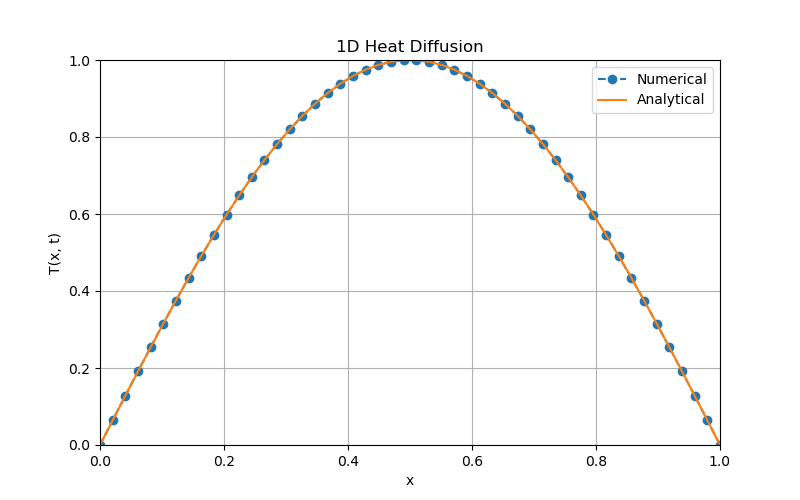

In [9]:
# 参数设置
L = 1.0  # 空间长度
Nx = 50  # 空间网格点数
dx = L / (Nx - 1)  # 空间步长
alpha = 0.01  # 热扩散系数
# dt = 0.1  # 时间步长
dt = dx**2 / (2 * alpha)
Nt = 500  # 时间步数

# 初始化温度场
x = np.linspace(0, L, Nx)  # 空间坐标
T = np.sin(np.pi * x)  # 初始条件 T(x, 0) = sin(pi * x)
T_new = np.zeros_like(T)  # 用于存储更新后的温度

# 解析解函数
def analytical_solution(x, t, alpha):
    return np.exp(-np.pi**2 * alpha * t) * np.sin(np.pi * x)

# 动画更新函数
def update(frame):
    global T, T_new
    t = frame * dt  # 当前时间

    # 显式有限差分法更新温度场
    for i in range(1, Nx - 1):
        T_new[i] = T[i] + alpha * dt / dx**2 * (T[i + 1] - 2 * T[i] + T[i - 1])

    # 边界条件
    T_new[0] = 0.0
    T_new[-1] = 0.0

    # 更新温度场
    T[:] = T_new[:]

    # 更新数值解和解析解曲线
    numerical_line.set_ydata(T)
    analytical_line.set_ydata(analytical_solution(x, t, alpha))

    # 更新标题
    ax.set_title(f"1D Heat Diffusion (t = {t:.3f}s)")

    return numerical_line, analytical_line

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, L)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("T(x, t)")
ax.set_title("1D Heat Diffusion")
ax.grid()

# 初始化数值解和解析解曲线
numerical_line, = ax.plot(x, T, label="Numerical", marker="o", linestyle="--")
analytical_line, = ax.plot(x, analytical_solution(x, 0, alpha), label="Analytical", linestyle="-")
ax.legend()

# 创建动画
ani = FuncAnimation(fig, update, frames=Nt, interval=50, blit=True, repeat=False)

# 显示动画
plt.show()

In [10]:
ani.event_source.stop()

---
# 第三部分：静态偏微分方程求解练习

## 利用松弛法，计算两个天体之间的引力势分布

利用松弛法，求解两个质量差一倍的天体之间的引力势分布。引力势满足泊松方程 $\nabla^2 \Phi = 4 \pi G \rho $（注意此处受限于代码复杂度，在二维空间求解，与三维空间的泊松方程解并不相同）。

在`301x201`的网格区域中，假设：
- 边界条件：常数边界条件，数值由初始值决定，如果迭代中不更新边界格点，则默认为此边界条件
- 密度分布：两天体密度值分别为 1 和 0.5 (单位：$M_\odot/R_\odot^3$)，距离为100 $R_\odot$，放置在x轴1/3和2/3处，y轴1/2处的两个格点上，其余格点密度为0。
- 引力常数: $G= 4 \pi^2 215^3$（$R_\odot^3 M_\odot^{-1} yr^{-2}$）
- 格点间距：dx = 1 （单位：$R_\odot$）
- 初始$\Phi$值：全零数组

以下代码实现了松弛法的迭代1000次过程，并绘制出势分布图，请补充完整缺失代码：
1. 补充完整密度分布数组rho的设置
2. 松弛法中间格点更新公式（令松弛因子$\omega=1$）
   - 参考公式：$u^{i,j}_{k+1} = u^{i,j}_k +  \frac{1}{4} \left(u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$，
   - 注意代码中Phi表示这里的u，同时密度rho前需补充系数 $4 \pi G$
   - 提示：可以用NumPy矢量化运算一次完成所有中间格点计算，或用双重for循环依次计算每个中间格点。建议用NumPy矢量化运算，效率要高很多

完成后，迭代1000次，对应效果图：
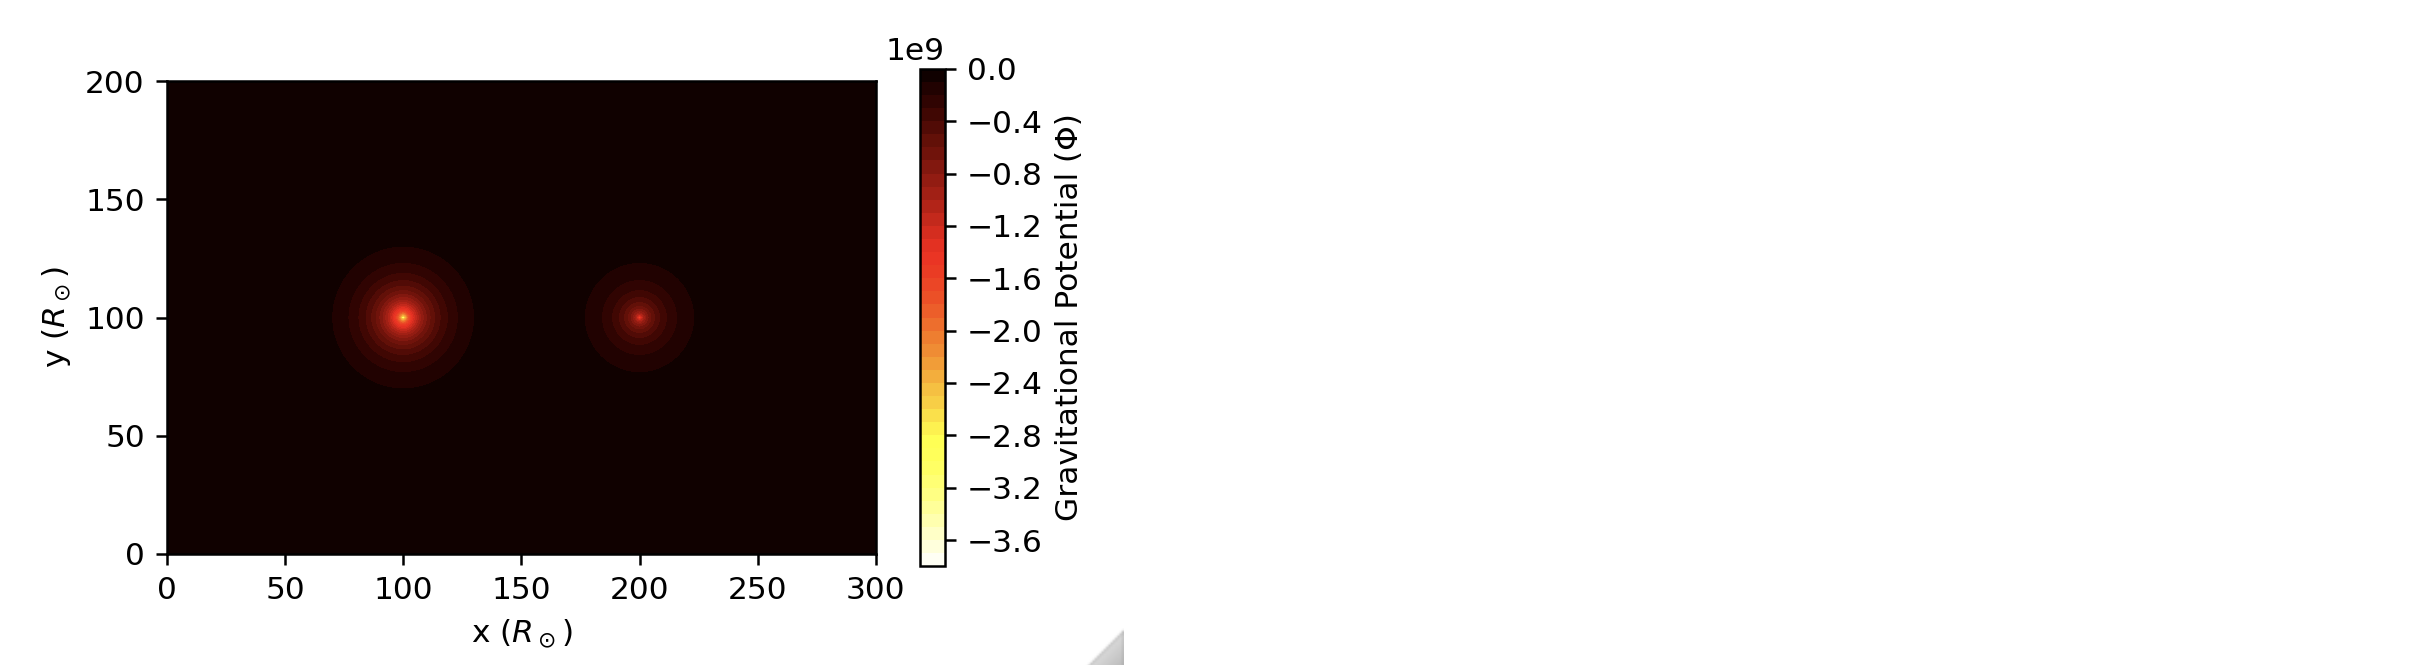

error: 784331.7829146385 iteration: 1000


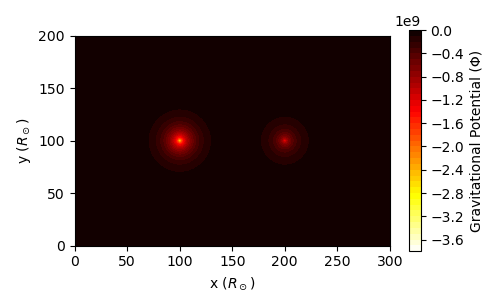

In [11]:
# 常量定义  
G = 4*np.pi**2*215**3  # 引力常数 (Rsun^3 Msun^-1 yr^-2)  
rho1 = 1  # 太阳质量 (Msun)  
rho2 = 0.5  # (Msun)  
dx = 1 # 太阳半径（Rsun)

# 网格参数  
nx, ny = 301, 201  # 网格点数
x = np.linspace(0, (nx-1)*dx, nx)  # x 方向范围  
y = np.linspace(0, (ny-1)*dx, ny)  # y 方向范围  
#print(G,dx)

# 初始化引力势
phi0 = np.zeros((nx, ny))  # 引力势  

# 初始化密度分布数组 
rho = np.zeros((nx, ny)) 
# rho[99,99],rho[199,99] = 4*np.pi*G*1,4*np.pi*G*0.5
# 这里是一个常见误区，因为X是从0开始的，而不是1，所以index到100就是100
rho[100,100],rho[200,100] = 4*np.pi*G*1,4*np.pi*G*0.5


# 松弛法迭代函数
def pde_relax(Phi0, rho, dx, tol=1e-6, max_iter=1000):
    '''
    Phi0: 初始化引力势数组
    rho: 密度数组，和phi同形状
    dx: 格点间距
    tol: 误差最大值
    max_iter: 最大迭代次数

    返回：
    phi: 满足泊松方程的引力势解
    err_max: 误差
    niter: 迭代次数
    '''
    
    niter = 0
    err_max = 10*tol

    Phi = Phi0.copy()
    
    while (err_max >tol) & (niter < max_iter):
        # 下一步Phi值存入Phi_new中
        Phi_new = Phi.copy()  

        # 中间格点更新 （请补充, Numpy 或 for循环二选一）
        # Numpy 实现

       

        Phi_new[1:-1,1:-1] = Phi[1:-1,1:-1] +(1/4)*(Phi[2:,1:-1]+Phi[:-2,1:-1]+Phi[1:-1,2:]+Phi[1:-1,:-2]-4*Phi[1:-1,1:-1]-dx**2*rho[1:-1,1:-1] )
        
        # # for 循环实现
        # for i in range(1, nx-1):  
        #     ...
        
        # 计算误差  
        err_max = np.max(np.abs(Phi_new - Phi))  

        # 更新 Phi为Phi_new
        Phi = Phi_new        
        
        # 增加迭代计数
        niter += 1

    return Phi, err_max, niter

# 使用函数求解
Phi, err_max, niter = pde_relax(phi0, rho, dx)
print('error:',err_max, 'iteration:',niter)

# 可视化引力势分布  
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.contourf(x, y, Phi.T, levels=40, cmap='hot_r')  
plt.colorbar(im, label='Gravitational Potential (Φ)')  
axes.set_xlabel(r'x ($R_\odot$)')  
axes.set_ylabel(r'y ($R_\odot$)')  
axes.set_aspect(1)
plt.tight_layout()

## 棋盘松弛法求解

利用下面实现的棋盘松弛法，替换上题中标准松弛法`pde_relax`函数，重新求解并绘制引力势分布图，并完成下面两部测试：
1. 迭代1000步，与上题中相比，误差好了多少，引力势分布是否改变？
2. 如果想让最大误差到$10^{-4}$，需要迭代多少步？

#### $\textcolor{red}{Note}$
这里代码是有相当一部分坑人的细节的...
1. 首先是关于常数
2. 然后是`pde_checkerbroad`的返回参数
3. 然后是`omega`的计算，应该是`np.min` instead of `np.max`

In [ ]:
G = 4*np.pi**2*215**3  # 引力常数 (Rsun^3 Msun^-1 yr^-2)  
rho1 = 1  # 太阳质量 (Msun)  
rho2 = 0.5  # (Msun)  
dx = 1 # 太阳半径（Rsun)

# 网格参数  
nx, ny = 301, 201  # 网格点数
x = np.linspace(0, (nx-1)*dx, nx)  # x 方向范围  
y = np.linspace(0, (ny-1)*dx, ny)  # y 方向范围  
#print(G,dx)

# 初始化引力势
phi0 = np.zeros((nx, ny))  # 引力势  

# 初始化密度分布数组 
rho = np.zeros((nx, ny)) 
# rho[99,99],rho[199,99] = 4*np.pi*G*1,4*np.pi*G*0.5
# 这里是一个常见误区，因为X是从0开始的，而不是1，所以index到100就是100
rho[100,100],rho[200,100] =1,0.5

# 松弛法迭代函数
def pde_checkerbroad(Phi0, rho, dx, tol=1e-6, max_iter=1000):
    '''
    Phi0: 初始化引力势数组
    rho: 密度数组，和phi同形状
    dx: 格点间距
    tol: 误差最大值
    max_iter: 最大迭代次数

    返回：
    phi: 满足泊松方程的引力势解
    err_max: 误差
    niter: 迭代次数
    '''

    omega = 2/(1+np.sin(np.pi/np.min(Phi0.shape)))
    
    niter = 0
    err_max = 10*tol

    Phi = Phi0.copy()

    # 重复迭代直到满足误差或迭代次数条件
    while (err_max >tol) & (niter < max_iter):

        Phi_old = Phi.copy()  

        # 迭代两次，奇偶交替更新
        for k in [0,1]:
            Phi_new = Phi.copy() 
            Phi_new[1:-1,1:-1] = Phi[1:-1,1:-1] + omega/4 * (Phi[2:,1:-1]+Phi[:-2,1:-1]+Phi[1:-1,2:]+Phi[1:-1,:-2] - 4*Phi[1:-1,1:-1] - dx**2 * 4*np.pi * G * rho[1:-1,1:-1])
    
            # 奇偶交替更新
            Phi[k::2,1::2] = Phi_new[k::2,1::2]
            Phi[1-k::2,::2] = Phi_new[1-k::2,::2]
    
        err_max = np.max(np.abs(Phi - Phi_old))  
        
        # 增加迭代计数
        niter += 1
    
    return Phi, err_max, niter, omega


# 使用函数求解
Phi, err_max, niter,_ = pde_checkerbroad(phi0, rho, dx)
print('error:',err_max, 'iteration:',niter)

# 可视化引力势分布  
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.contourf(x, y, Phi.T, levels=40, cmap='hot_r')  
plt.colorbar(im, label='Gravitational Potential (Φ)')  
axes.set_xlabel(r'x ($R_\odot$)')  
axes.set_ylabel(r'y ($R_\odot$)')  
axes.set_aspect(1)
plt.tight_layout()

## 松弛法改造为超松弛法

将第一题实现的`pde_relax`函数由松弛法改造为超松弛法`pde_sor`，并使用与棋盘松弛法`pde_checkerboard`相同的松弛因子`omega`计算方法。

超松弛法迭代公式（注意与`pde_relax`中的公式相比，左格点和上格点由上一步值改为本次循环已计算得到的值）：

$u^{i,j}_{k+1} = u^{i,j}_k +  \frac{1}{4}{\omega} \left(u^{i+1,j}_k + u^{i-1,j}_{k+1} + u^{i,j+1}_k + u^{i,j-1}_{k+1} - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$

具体实现步骤：
1. 将`pde_relax`的中间格点计算迭代方式改为在双重for循环中直接更新`Phi`，而不是存入`Phi_new`中（如在`pde_relax`中使用NumPy矢量化运算，改用双重for循环可感受到明显的执行效率下降）。
2. 在计算公式中增加松弛因子`omega`，并将`pde_checkerboard`中的松弛因子计算方法复制过来。
3. 利用实现的超松弛法重新实现第一题的引力势计算，迭代1000次后，误差能够达到多少，和棋盘松弛法相比如何？

Auto omega = 1.9692
error: 9.9724597402151e-07 iteration: 592


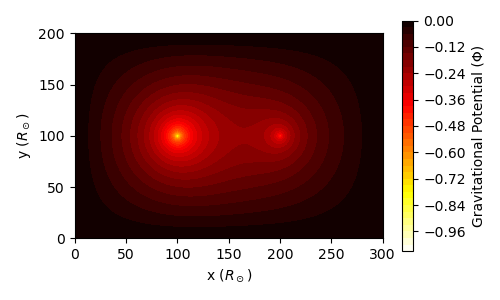

In [12]:
G = 4*np.pi**2*215**3  # 引力常数 (Rsun^3 Msun^-1 yr^-2)  
rho1 = 1  # 太阳质量 (Msun)  
rho2 = 0.5  # (Msun)  
dx = 1 # 太阳半径（Rsun)

# 网格参数  
nx, ny = 301, 201  # 网格点数
x = np.linspace(0, (nx-1)*dx, nx)  # x 方向范围  
y = np.linspace(0, (ny-1)*dx, ny)  # y 方向范围  
#print(G,dx)

# 初始化引力势
phi0 = np.zeros((nx, ny))  # 引力势  

# 初始化密度分布数组 
rho = np.zeros((nx, ny)) 
# rho[99,99],rho[199,99] = 4*np.pi*G*1,4*np.pi*G*0.5
# 这里是一个常见误区，因为X是从0开始的，而不是1，所以index到100就是100
rho[100,100],rho[200,100] =1,0.5

def pde_sor(Phi0, rho, dx, omega=None, tol=1e-6, max_iter=1000):
    '''
    超松弛法（Successive Over-Relaxation）求解二维泊松方程
    与 pde_relax 的区别：
      - 使用双重 for 循环原地更新 Phi
      - 左/上邻居自动采用本轮已更新的新值
      - 引入松弛因子 omega（默认按棋盘法公式计算最优值）
    '''
    nx, ny = Phi0.shape
    
    # 若未指定 omega，使用与棋盘法相同的最优松弛因子
    if omega is None:
        N = min(nx, ny)
        omega = 2 / (1 + np.sin(np.pi / N))
        print(f'Auto omega = {omega:.4f}')
    
    Phi = Phi0.copy()
    niter = 0
    err_max = 10 * tol

    while (err_max > tol) and (niter < max_iter):
        # 必须在循环开始前备份，用于后面计算误差
        Phi_old = Phi.copy()

        # 双重 for 循环：i 从左到右，j 从上到下
        for i in range(1, nx - 1):
            for j in range(1, ny - 1):
                # 注意：Phi[i-1, j] 和 Phi[i, j-1] 可能已经是本轮更新后的新值
                residual = (Phi[i+1, j] + Phi[i-1, j] 
                          + Phi[i, j+1] + Phi[i, j-1] 
                          - 4 * Phi[i, j] 
                          - dx**2 * rho[i, j])
                
                # 原地更新，直接改写 Phi[i, j]
                Phi[i, j] = Phi[i, j] + (omega / 4) * residual

        # 边界保持初始值（Dirichlet 0），无需额外处理，因为我们只改了内部
        
        err_max = np.max(np.abs(Phi - Phi_old))
        niter += 1

    return Phi, err_max, niter

# 使用函数求解
Phi, err_max, niter = pde_sor(phi0, rho, dx)
print('error:',err_max, 'iteration:',niter)

# 可视化引力势分布  
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.contourf(x, y, Phi.T, levels=40, cmap='hot_r')  
plt.colorbar(im, label='Gravitational Potential (Φ)')  
axes.set_xlabel(r'x ($R_\odot$)')  
axes.set_ylabel(r'y ($R_\odot$)')  
axes.set_aspect(1)
plt.tight_layout()

## 使用谱方法离散正弦变换求解

对第一题中的双天体引力势问题，请阅读下面的离散正弦变换方法，使用该方法求解，并绘制引力势分布图。

In [13]:
def pde_dst_2d(rho, dx, dy):  
    """  
    使用离散正弦变换（DST）求解二维泊松方程 Δu = f, Dirichlet 边界条件 u=0 的解 
    参数:  
        rho: 源项函数值的二维数组 (Nx, Ny)  
        dx: x 方向的网格间距  
        dy: y 方向的网格间距  
    返回:  
        u: 解的二维数组 (Nx, Ny)  
    """  

    from scipy.fftpack import dstn, idstn
    
    # 获取网格大小  
    Nx, Ny = rho.shape  

    # 离散正弦变换（DST-II）对 f 进行变换  
    dst_rho = dstn(rho, norm='ortho')
 
    # 计算特征值（拉普拉斯算子的离散特征值）  
    kx = np.arange(1,Nx+1)  
    ky = np.arange(1,Ny+1)  
    lambda_x = 2 * (np.cos(np.pi*kx/(Nx+1)) - 1) / dx**2  
    lambda_y = 2 * (np.cos(np.pi*ky/(Ny+1)) - 1) / dy**2  

    # 构造拉普拉斯算子的特征值矩阵  
    lambda_matrix = np.add.outer(lambda_x, lambda_y)

    # 求解 dst_u  
    dst_u =  dst_rho / lambda_matrix  

    # 逆离散正弦变换（IDST-II）恢复解  
    u = idstn(dst_u, norm='ortho')  

    return u  

error: 9.9724597402151e-07 iteration: 592


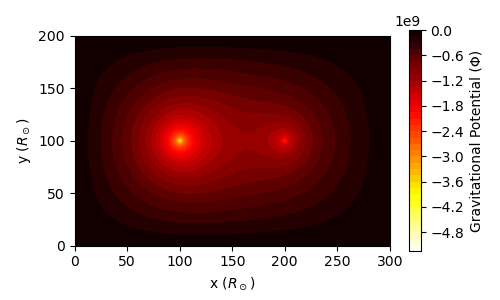

In [14]:
G = 4*np.pi**2*215**3  # 引力常数 (Rsun^3 Msun^-1 yr^-2)  
rho1 = 1  # 太阳质量 (Msun)  
rho2 = 0.5  # (Msun)  
dx,dy = 1,1 # 太阳半径（Rsun)

# 网格参数  
nx, ny = 301, 201  # 网格点数
x = np.linspace(0, (nx-1)*dx, nx)  # x 方向范围  
y = np.linspace(0, (ny-1)*dx, ny)  # y 方向范围  
#print(G,dx)

# 初始化引力势
phi0 = np.zeros((nx, ny))  # 引力势  

# 初始化密度分布数组 
rho = np.zeros((nx, ny)) 
# rho[99,99],rho[199,99] = 4*np.pi*G*1,4*np.pi*G*0.5
# 这里是一个常见误区，因为X是从0开始的，而不是1，所以index到100就是100
rho[100,100],rho[200,100] =4*np.pi*G*1,4*np.pi*G*0.5

Phi = pde_dst_2d(rho, dx,dy)
print('error:',err_max, 'iteration:',niter)

# 可视化引力势分布  
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.contourf(x, y, Phi.T, levels=40, cmap='hot_r')  
plt.colorbar(im, label='Gravitational Potential (Φ)')  
axes.set_xlabel(r'x ($R_\odot$)')  
axes.set_ylabel(r'y ($R_\odot$)')  
axes.set_aspect(1)
plt.tight_layout()
